In [1]:
# Show plots inline, and load main getdist plot module and samples class
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

# import libraries:
import sys, os
#os.environ['TF_USE_LEGACY_KERAS'] = '1'  # needed for tensorflow KERAS compatibility
os.environ['DISPLAY'] = 'inline'  # hack to get getdist working
sys.path.insert(0,os.path.realpath(os.path.join(os.getcwd(),'../..')))
from getdist import plots, MCSamples
from getdist.gaussian_mixtures import GaussianND
import getdist
getdist.chains.print_load_details = False
import scipy
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# tensorflow imports:
import tensorflow as tf
import tensorflow_probability as tfp

# import the tensiometer tools that we need:
import tensiometer
from tensiometer.utilities import stats_utilities as utilities
from tensiometer.synthetic_probability import synthetic_probability as sp

# getdist settings to ensure consistency of plots:
getdist_settings = {'ignore_rows': 0.3, 
                    'smooth_scale_2D': 0.5,
                    'smooth_scale_1D': 0.5,
                    }    

2025-07-30 14:35:44.554313: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-30 14:35:44.750374: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-30 14:35:44.750458: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-30 14:35:44.790362: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-30 14:35:44.866048: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-30 14:35:44.868164: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [3]:
# ADD MY CHAINS:
# Loading samples
#PLANCK_ALL
#lcdm:
chain_lcdm = os.path.join('/home/andrewcats/tesi_magistrale/lcdm/planck_all', '1_lcdm_planck_desidr2_des')
samples_lcdm = getdist.mcsamples.loadMCSamples(file_root=chain_lcdm, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_lcdm = [param.name for param in samples_lcdm.paramNames.names]
print(param_names_lcdm)


['logA', 'ns', 'theta_MC_100', 'ombh2', 'omch2', 'tau', 'A_planck', 'cal100A', 'cal100B', 'cal143B', 'cal217A', 'cal217B', 'Aradio', 'Adusty', 'AdustT', 'beta_dustT', 'Acib', 'beta_cib', 'Atsz', 'Aksz', 'xi', 'AdustP', 'beta_dustP', 'A', 'As', 'DHBBN', 'YHe', 'Y_p', 'age', 'clamp', 'H0', 'omegam', 'omegamh2', 'zre', 'sigma8', 's8h5', 's8omegamp5', 's8omegamp25', 'rdrag', 'beta_dusty', 'chi2__BAO', 'chi2__CMB', 'chi2__SN', 'minuslogprior', 'minuslogprior__0', 'chi2', 'chi2__sn.desy5', 'chi2__bao.desi_dr2.desi_bao_all', 'chi2__planck_2018_lowl.TT', 'chi2__planck_2020_lollipop.lowlB', 'chi2__planck_2020_lollipop.lowlEB', 'chi2__planck_2020_hillipop.TTTEEE']


In [4]:
kwargs = {
          'feedback': 1,
          'verbose': -1,
          'plot_every': 1000,
          'pop_size': 1,
          'num_flows': 2,
          'epochs': 50,
          #'loss_mode': 'softadapt'
        }



In [5]:
param_names_flow_lcdm = ['logA', 'ns', 'ombh2', 'omch2', 'tau', 'H0', 'omegam', 'sigma8'] # lcdm
average_flow_lcdm = sp.average_flow_from_chain(samples_lcdm, param_names = param_names_flow_lcdm, **kwargs)

Training flow 0


/home/andrewcats/anaconda3/envs/tensiometer_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 50/50 [01:11<00:00,  1.44s/epoch, loss=6.31, val_loss=6.37, lr=0.001]


Training flow 1


100%|██████████| 50/50 [01:17<00:00,  1.55s/epoch, loss=5.29, val_loss=5.66, lr=0.001]


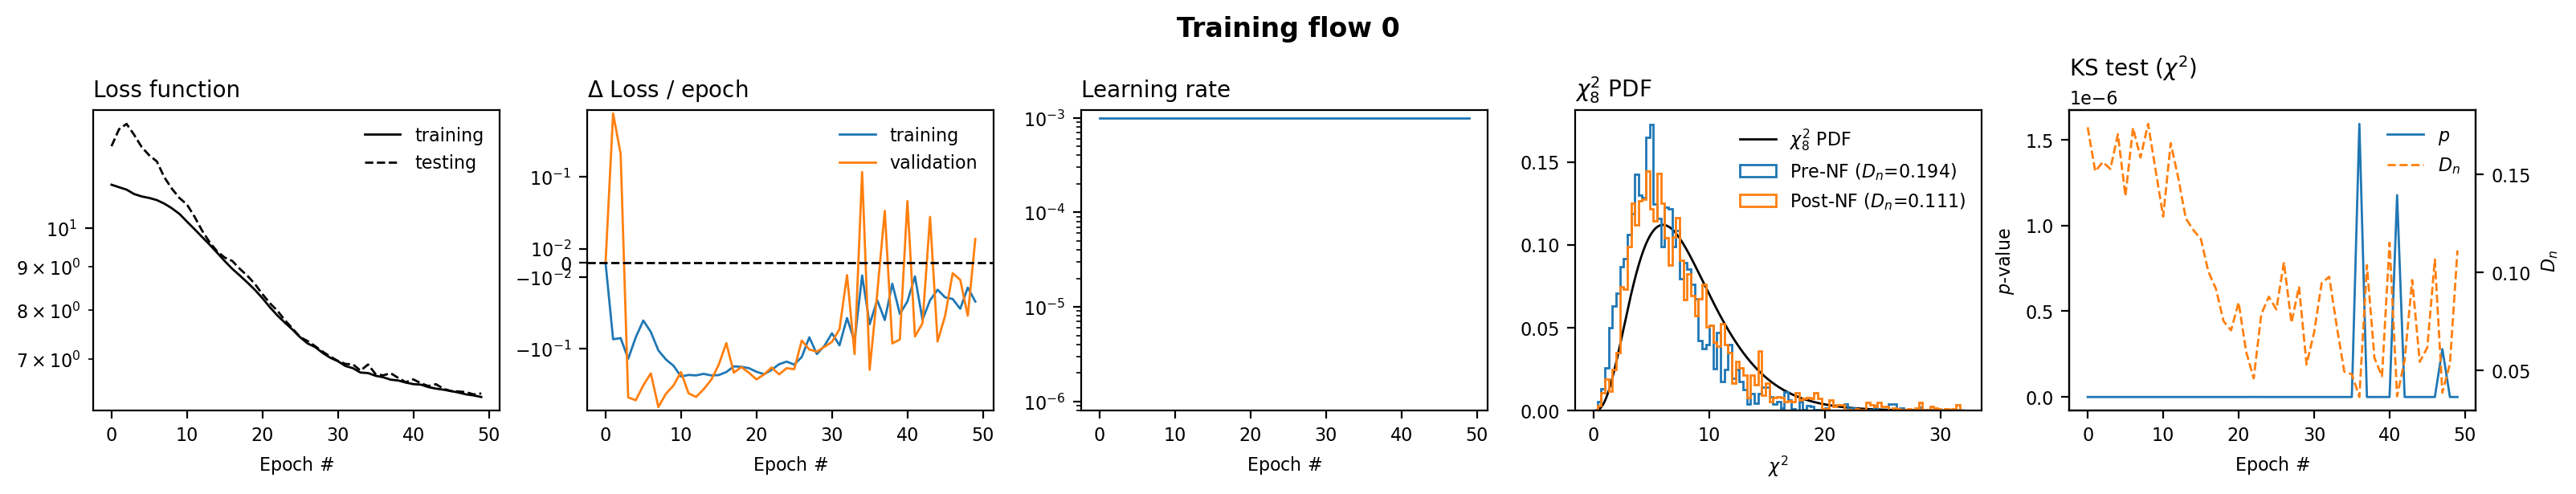

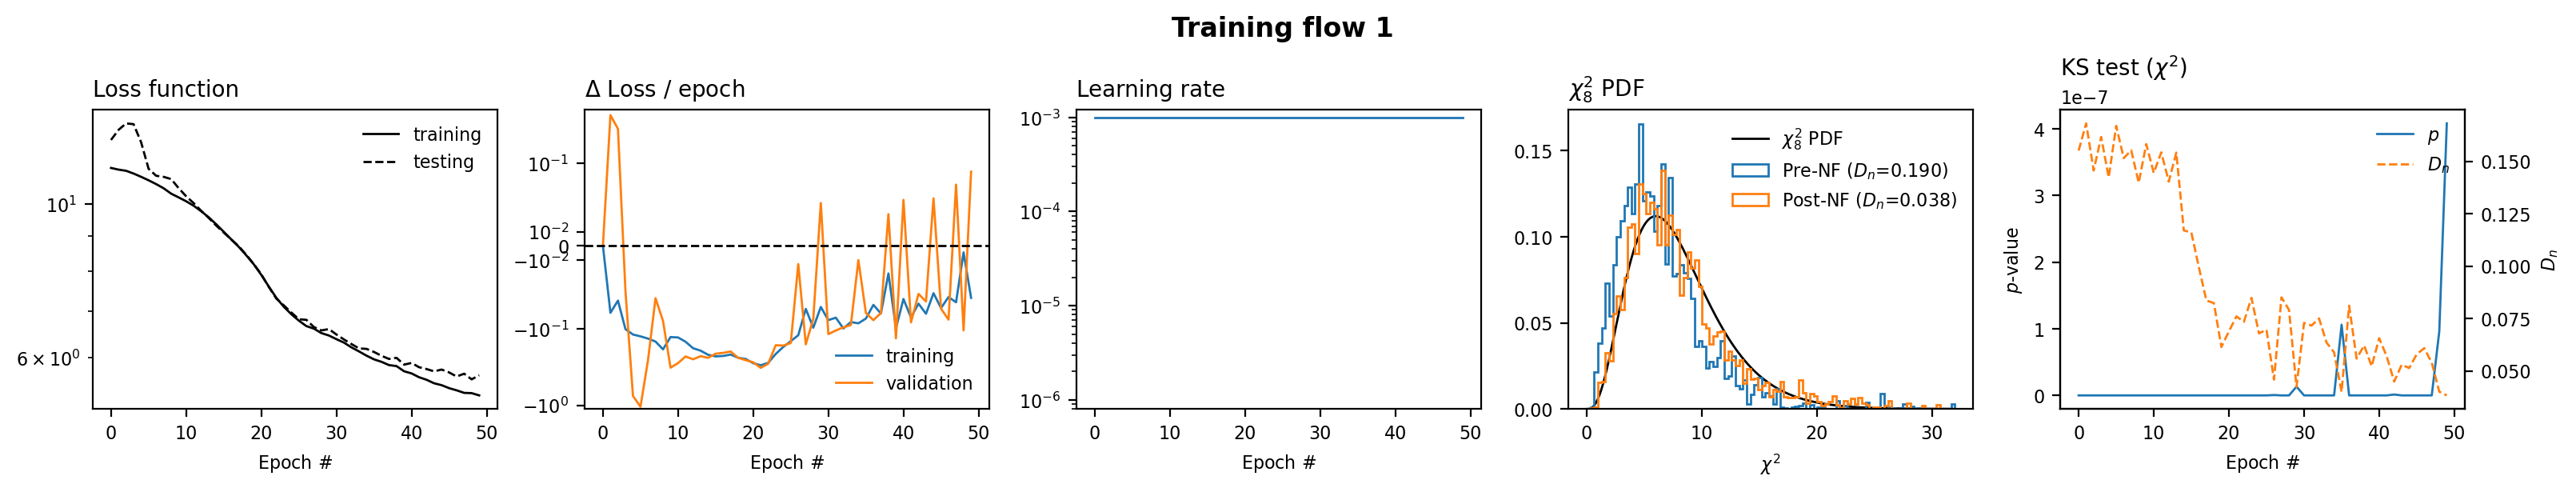

In [6]:
# most methods are implemented for the average flow as well:
average_flow_lcdm.training_plot()

In [7]:
# and we can print the training summary, which in this case contains more info:
average_flow_lcdm.print_training_summary()

Number of flows: 2
Flow weights   : [0.33 0.67]
loss         : [6.31 5.29]
val_loss     : [6.37 5.66]
lr           : [0. 0.]
chi2Z_ks     : [0.11 0.04]
chi2Z_ks_p   : [7.36e-57 4.08e-07]
loss_rate    : [-0.03 -0.04]
val_loss_rate: [0.02 0.08]


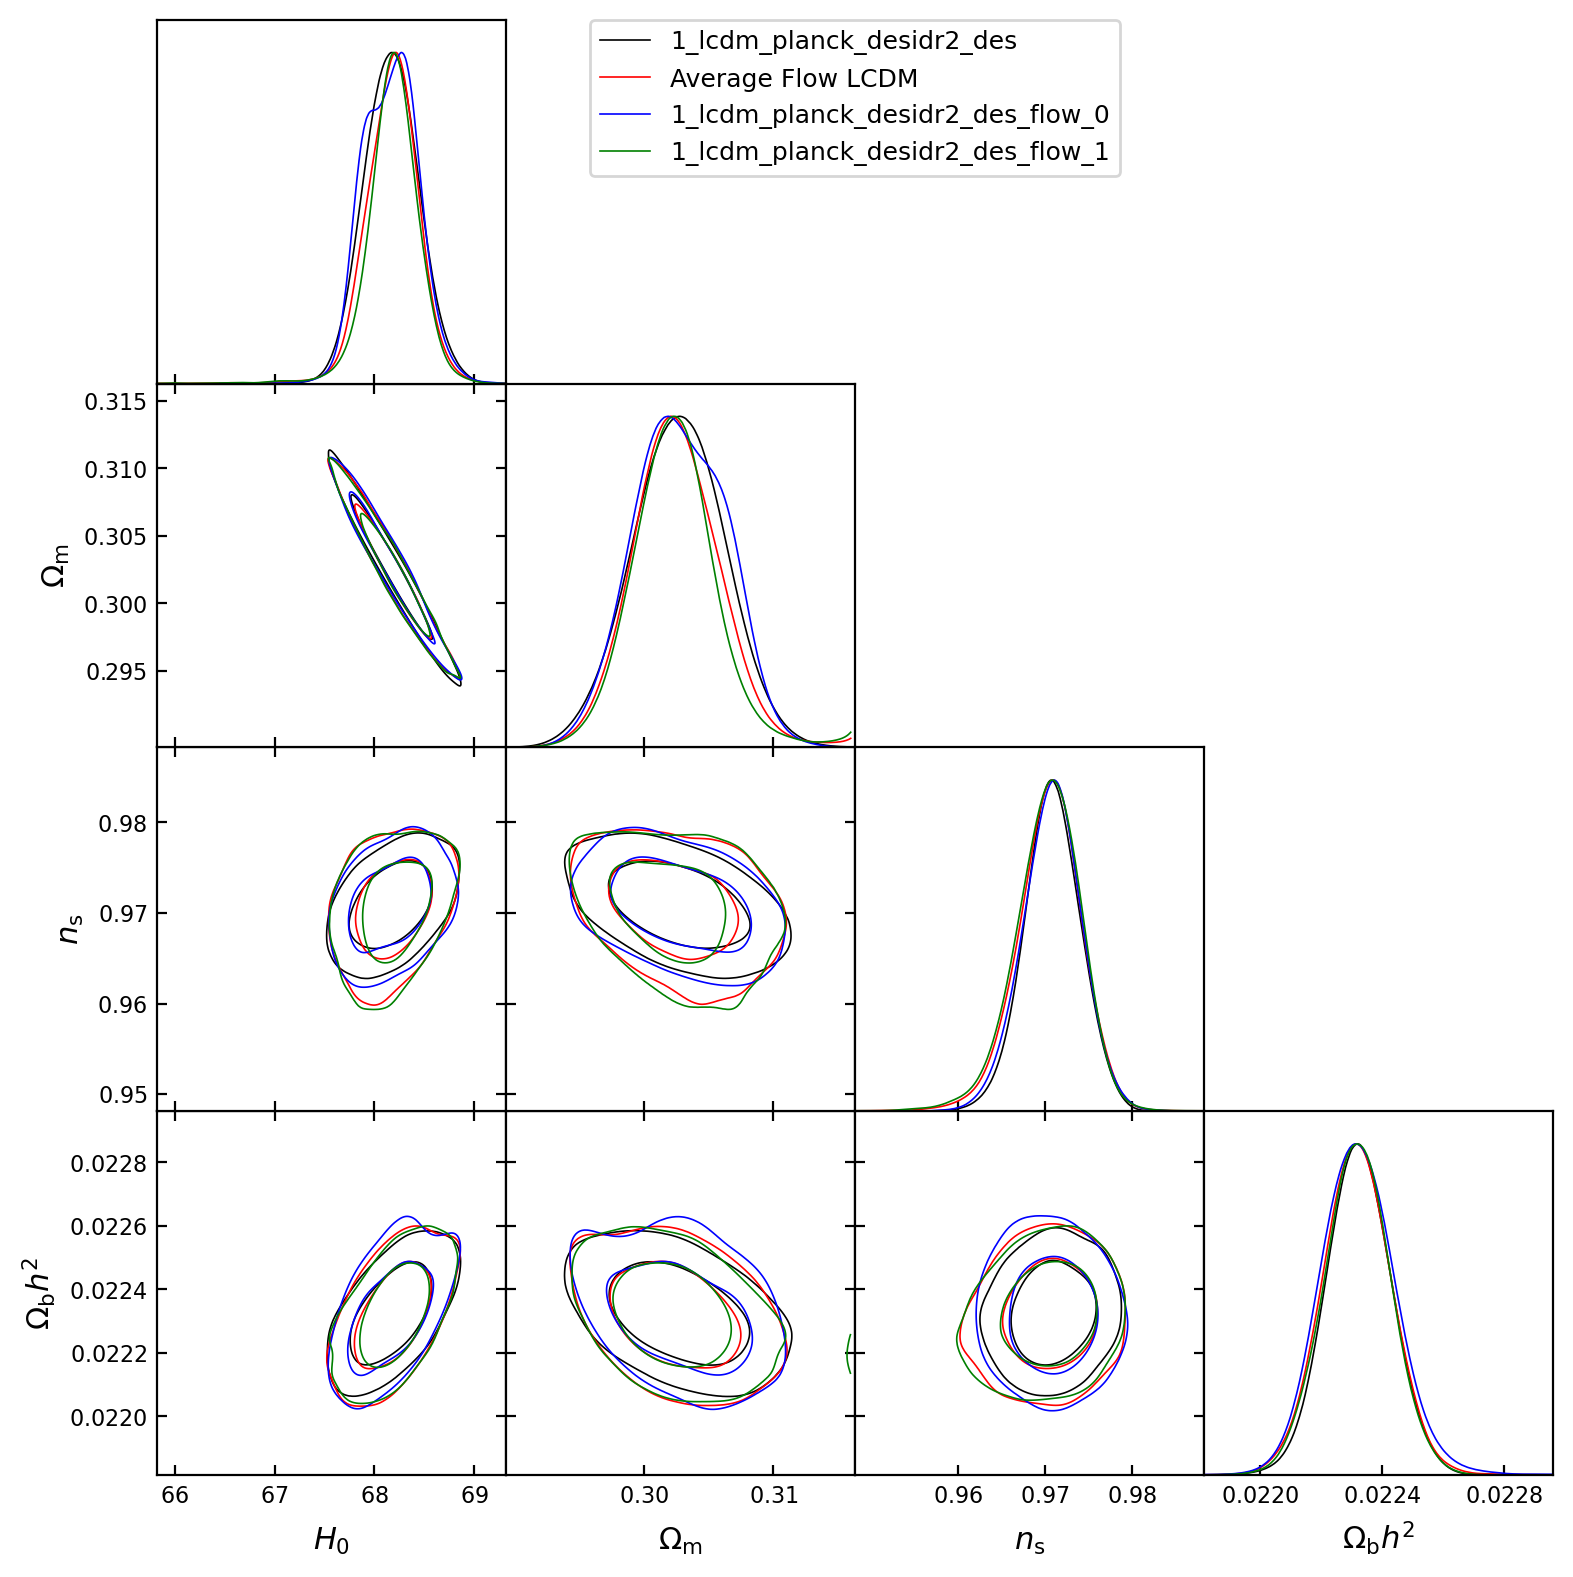

In [8]:

avg_samples_lcdm = average_flow_lcdm.MCSamples(20000)
avg_samples_lcdm.name_tag = 'Average Flow LCDM'
temp_samples_lcdm = [_f.MCSamples(20000) for _f in average_flow_lcdm.flows]
for i, _s in enumerate(temp_samples_lcdm):
    _s.name_tag = _s.name_tag + f'_{i}'
# let's plot the flows:
params_to_plot = ['H0', 'omegam', 'ns', 'ombh2']
g = plots.get_subplot_plotter()
g.triangle_plot([samples_lcdm, avg_samples_lcdm] + temp_samples_lcdm,
                params=params_to_plot,
                filled=False)


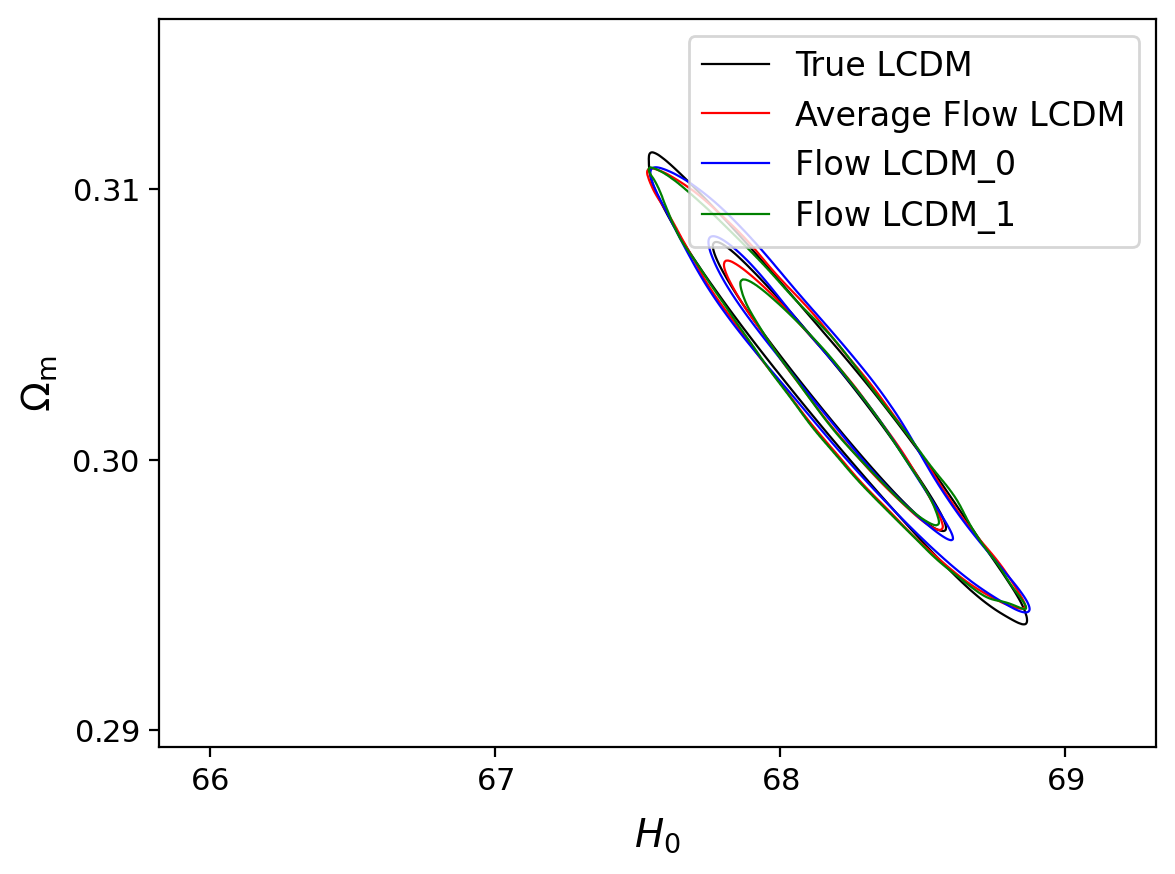

In [9]:
# 2D Plot H0 and omega_m
# Set all line widths to 0.8 (or whatever you like)
n_total = 2 + len(temp_samples_lcdm)  # total number of samples being plotted
line_args = [{'lw': 0.8}] * n_total  # same style for all

# Create name tags and labels
for i, _s in enumerate(temp_samples_lcdm):
    _s.name_tag = f'Flow LCDM_{i}'
labels = ['True LCDM', 'Average Flow LCDM'] + [s.name_tag for s in temp_samples_lcdm]

# Plot
g = plots.get_single_plotter()
g.plot_2d([samples_lcdm, avg_samples_lcdm] + temp_samples_lcdm,
          ['H0', 'omegam'],
          line_args=line_args)

g.add_legend(labels)



Remove Evidence

In [11]:
def compute_evidence_from_flow(samples_obj, flow_log_prob_fn, flow_param_names, param_names_all,
                               indexes=None, weighted=False):
    """
    Compute evidence using a normalizing flow and GetDist's MCSamples object.

    Parameters:
    - samples_obj (MCSamples): GetDist MCSamples instance.
    - flow_log_prob_fn (callable): Function to compute log-probabilities from flow.
    - flow_param_names (list): Names of the parameters used by the flow.
    - param_names_all (list): All parameter names in the MCSamples object.
    - indexes (ndarray or None): Optional subset of samples.
    - weighted (bool): Whether to use chi² weighting.

    Returns:
    - (float, float): (evidence estimate, uncertainty)
    """
    if indexes is not None:
        _samples = samples_obj.samples[indexes]
        _loglikes = samples_obj.loglikes[indexes]
        _weights = samples_obj.weights[indexes]
    else:
        _samples = samples_obj.samples
        _loglikes = samples_obj.loglikes
        _weights = samples_obj.weights

    flow_log_likes = flow_log_prob_fn(_samples)

    # Use number of parameters relevant to the flow only
    num_params = len([param_names_all.index(p) for p in flow_param_names])

    if weighted:
        chi2_weights = scipy.stats.chi2.sf(2.0 * (_loglikes - np.min(_loglikes)), num_params)
        _weights = _weights * chi2_weights

    # Compute residuals
    diffs = -_loglikes - flow_log_likes

    # Weighted average and variance
    average = np.average(diffs, weights=_weights)
    variance = np.average((diffs - average)**2, weights=_weights)

    return average, np.sqrt(variance)


In [ ]:
# Convert param names in samples to strings
stri = ['logA', 'ns', 'theta_MC_100', 'ombh2', 'omch2', 'tau', 'A_planck', 'cal100A', 'cal100B', 'cal143B', 'cal217A', 'cal217B', 'Aradio', 'Adusty', 'AdustT', 'beta_dustT', 'Acib', 'beta_cib', 'Atsz', 'Aksz', 'xi', 'AdustP', 'beta_dustP', 'A', 'As', 'DHBBN', 'YHe', 'Y_p', 'age', 'clamp', 'H0', 'omegam', 'omegamh2', 'zre', 'sigma8', 's8h5', 's8omegamp5', 's8omegamp25', 'rdrag', 'beta_dusty', 'chi2__BAO', 'chi2__CMB', 'chi2__SN', 'minuslogprior', 'minuslogprior__0', 'chi2', 'chi2__sn.desy5', 'chi2__bao.desi_dr2.desi_bao_all', 'chi2__planck_2018_lowl.TT', 'chi2__planck_2020_lollipop.lowlB', 'chi2__planck_2020_lollipop.lowlEB', 'chi2__planck_2020_hillipop.TTTEEE']

param_names_all = [str(p) for p in stri]

# Params used in the flow
param_names = average_flow_lcdm.param_names
print(param_names)
# Get corresponding indices
param_indices = [param_names_all.index(p) for p in param_names]

In [12]:
def make_flow_log_prob_fn(flow, param_names_all, flow_param_names):
    param_indices = [param_names_all.index(p) for p in flow_param_names]

    def flow_log_prob_fn(samples):
        x = samples[:, param_indices].astype(np.float32)
        casted = flow.cast(x)
        return flow.log_probability(casted).numpy()

    return flow_log_prob_fn


flow_log_prob_fn = make_flow_log_prob_fn(average_flow_lcdm, param_names_all, average_flow_lcdm.param_names)

# Compute evidence
evidence, error = compute_evidence_from_flow(samples_lcdm, flow_log_prob_fn, average_flow_lcdm.param_names, param_names_all, weighted=False) # True, False
print("Evidence:", evidence, "+/-", error)


Evidence: -16215.540133109349 +/- 3.9914678731010174


First few values of validation_flow_log10_P: [19.440498 18.802422 18.678606]
First few values of training_flow_log10_P: [21.657028 16.869135 15.700036]
Mean training difference: 0.021252222351724536
Mean validation difference: -0.003157145542247638
Training flow difference: [-0.55586127 -2.35754571 -1.13020761]
Validation flow difference: [-2.4682961   0.33019935 -0.39120539]
Threshold training: 5.190990118274651
Threshold validation: 5.5473062951666545
Number of training points far from the mean: 321
Number of validation points far from the mean: 36


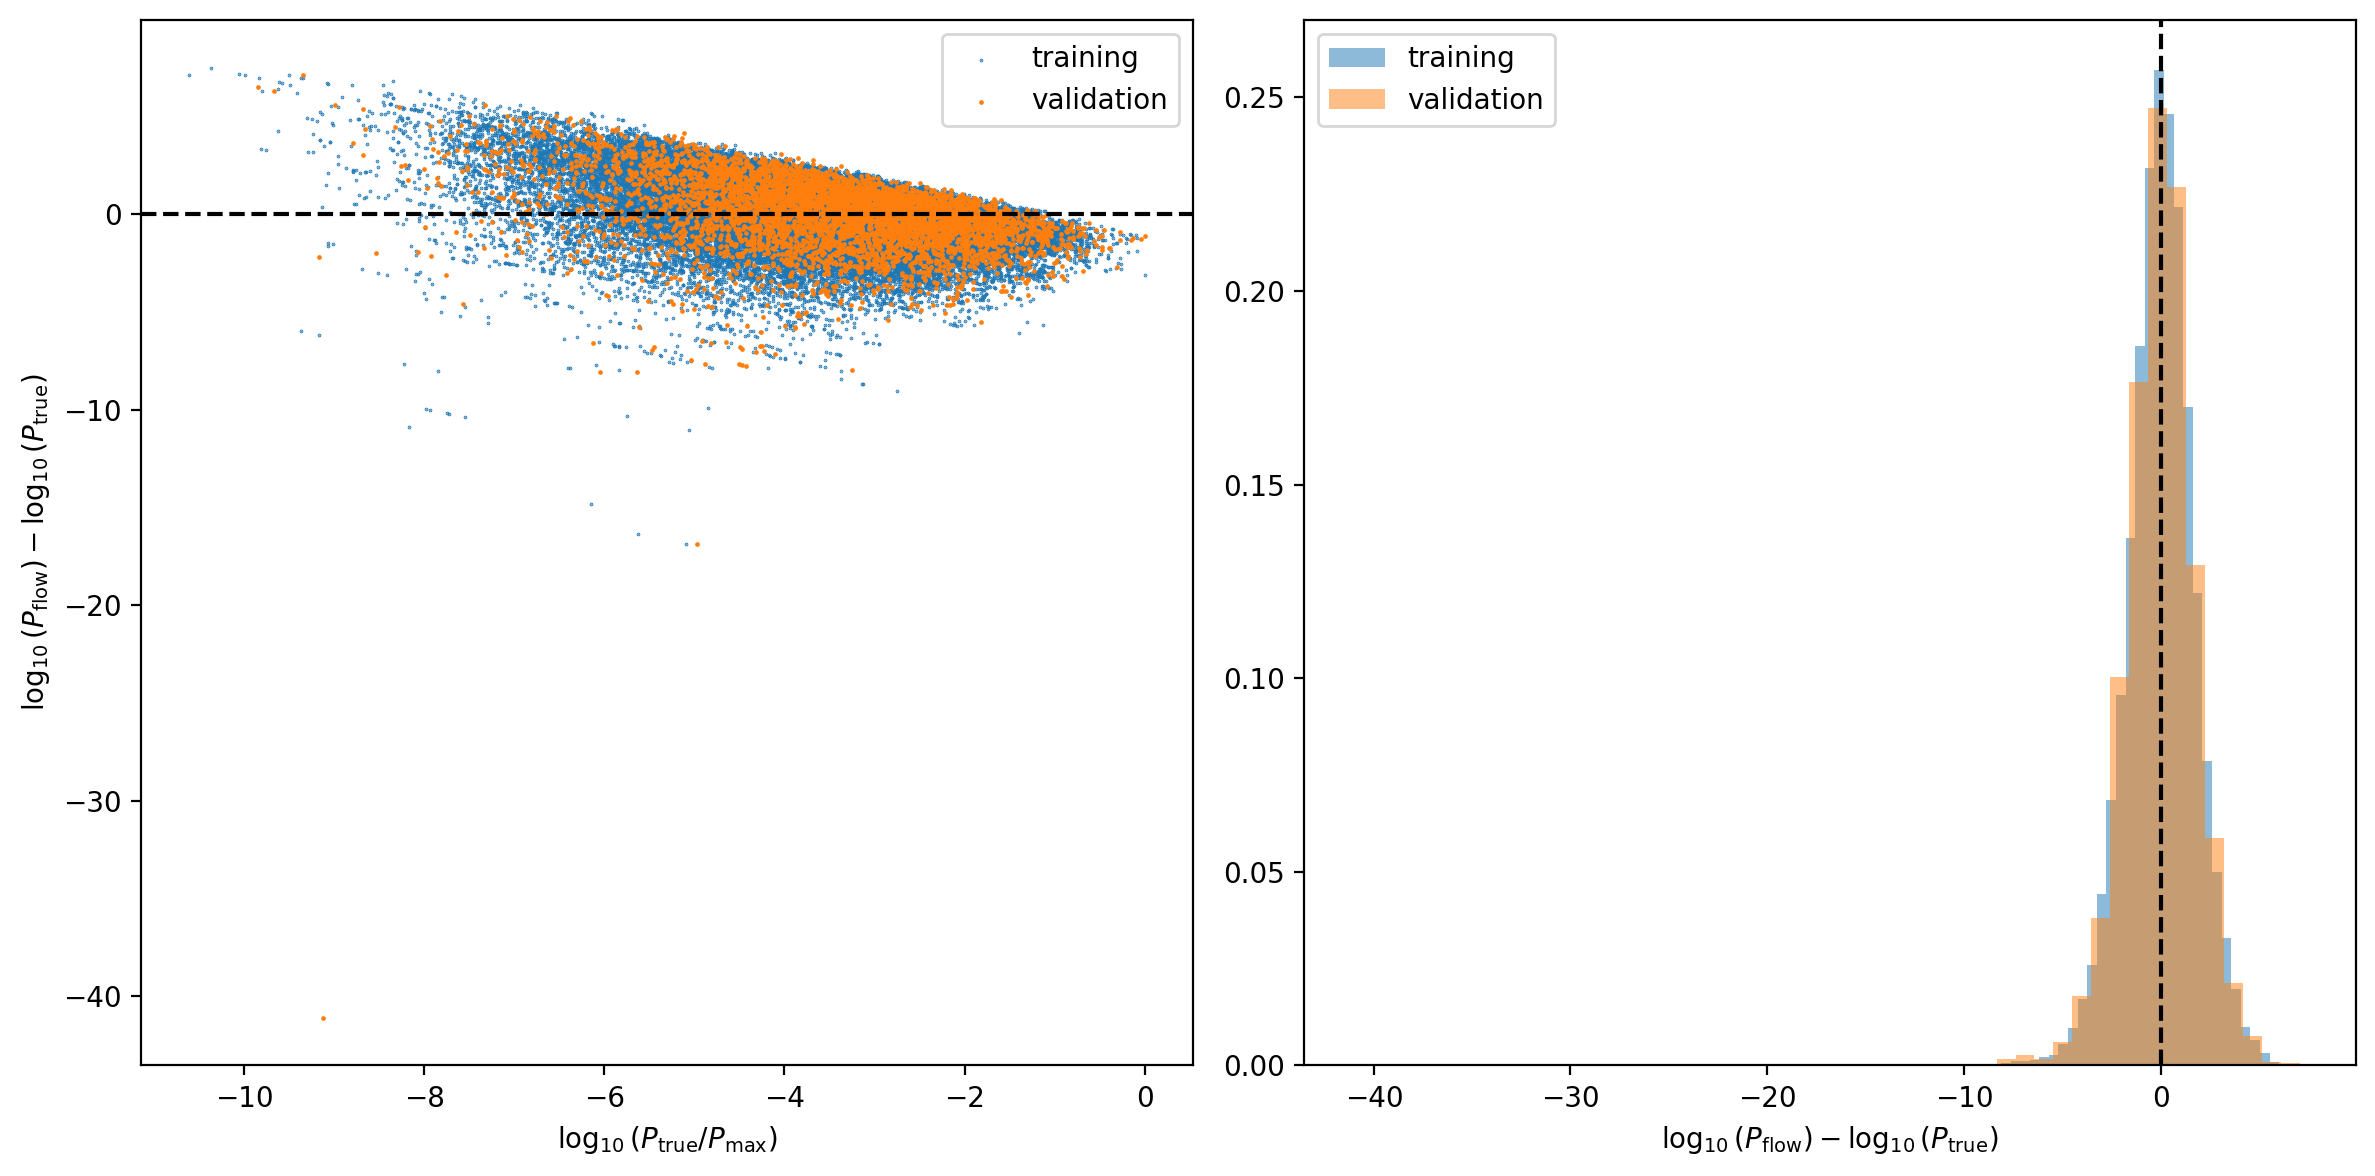

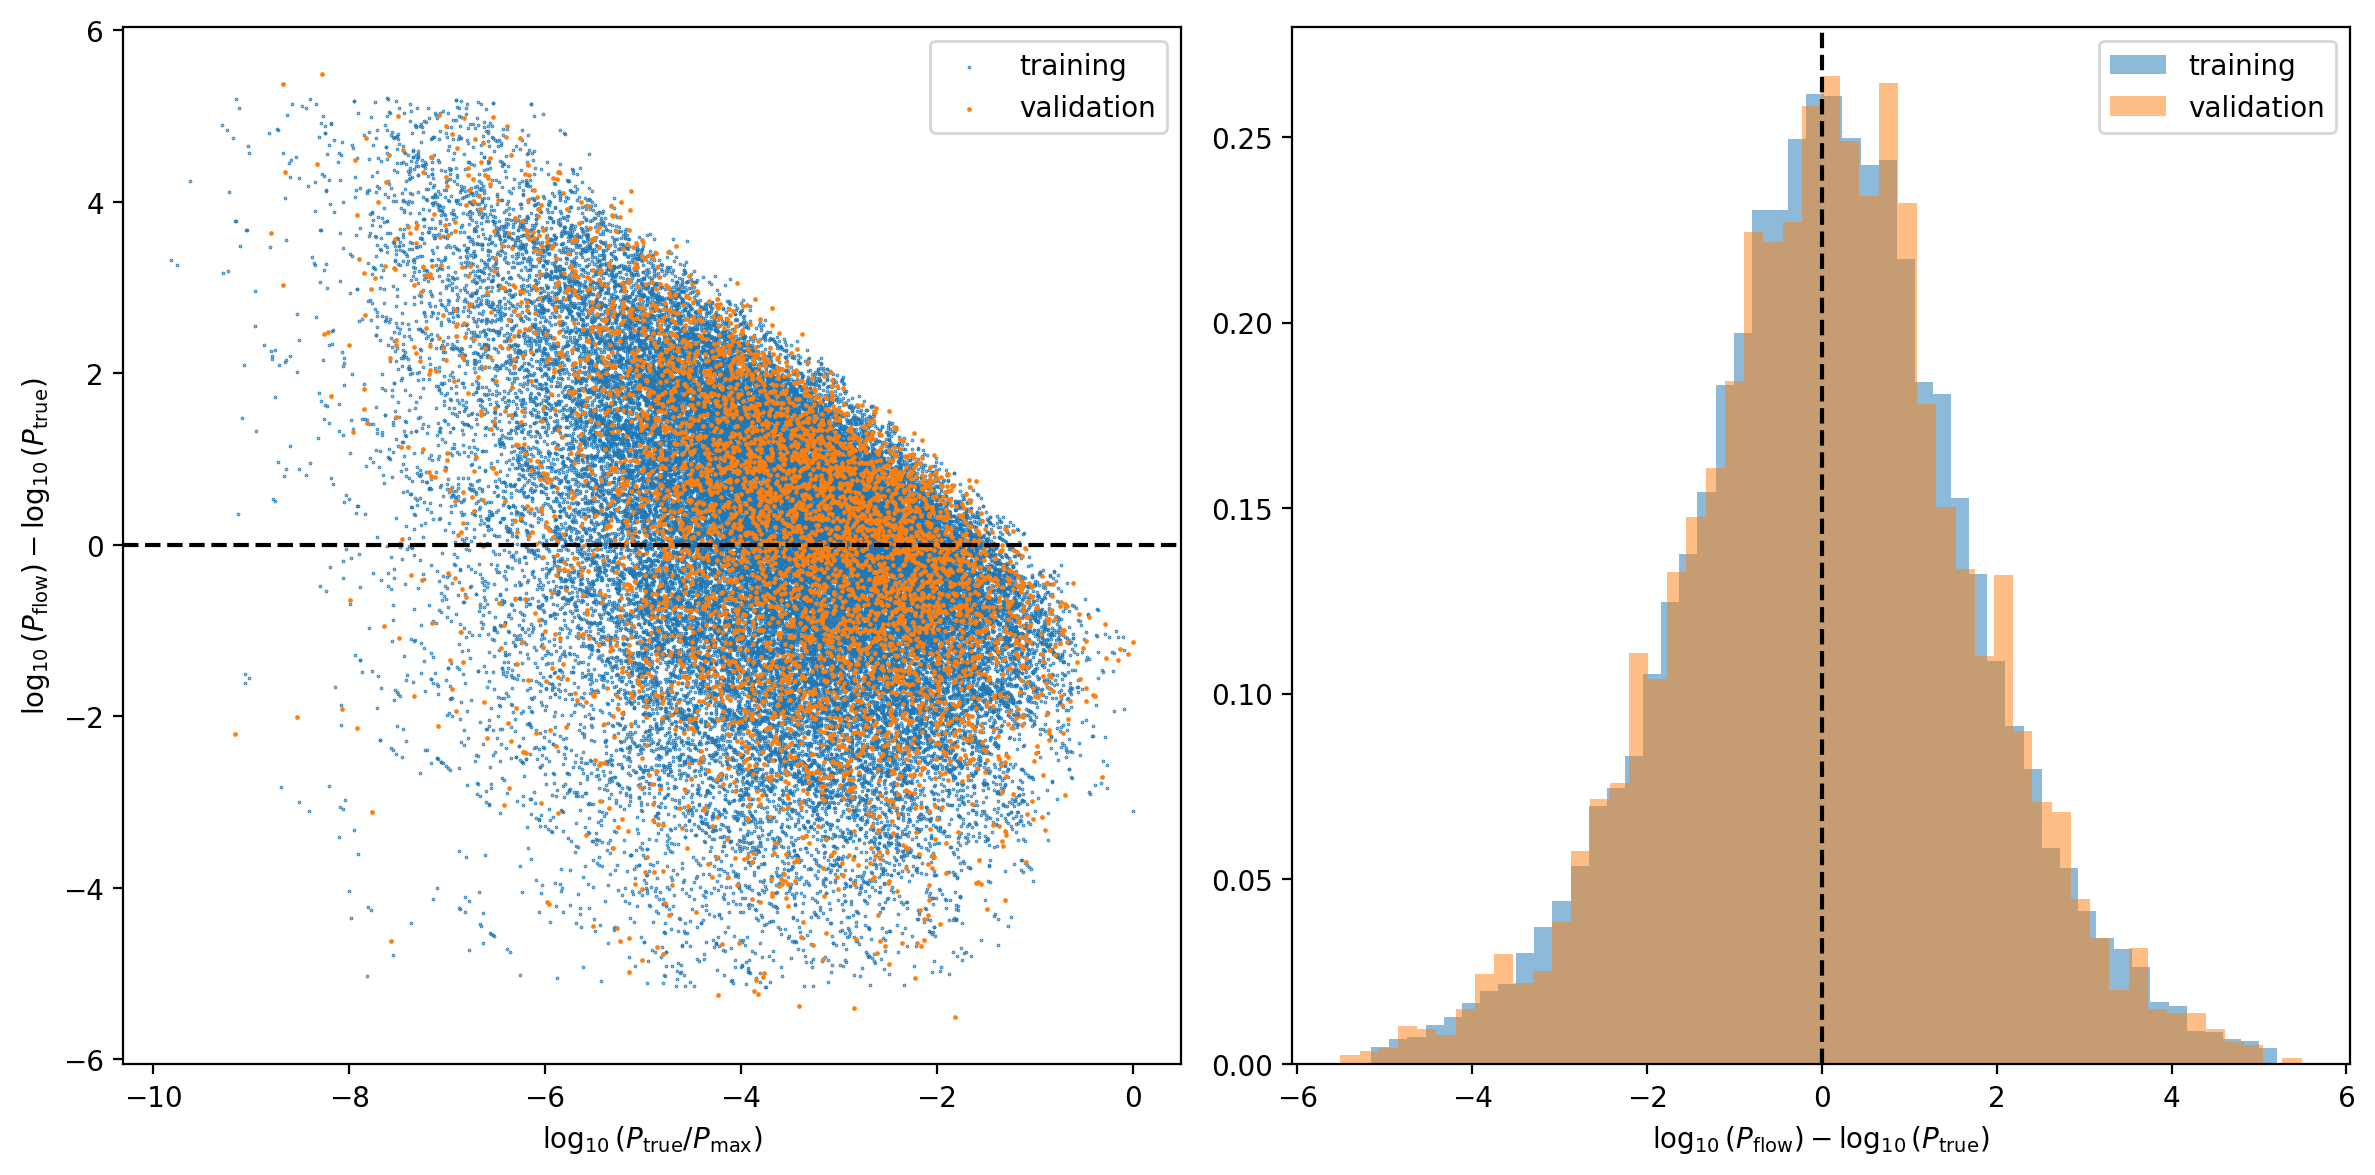

In [15]:

# Select only the needed parameters from test samples
x = samples_lcdm.samples[average_flow_lcdm.test_idx][:, param_indices].astype(np.float32)

# Cast and compute log-probability
casted = average_flow_lcdm.cast(x)

validation_flow_log10_P = average_flow_lcdm.log_probability(casted).numpy() / np.log(10.) # VALIDATION FLOW
# Print the first few values of validation_flow_log10_P
print("First few values of validation_flow_log10_P:", validation_flow_log10_P[:3])

x_training = samples_lcdm.samples[average_flow_lcdm.training_idx][:, param_indices].astype(np.float32)

# Cast and compute log-probability for training samples
casted_training = average_flow_lcdm.cast(x_training)
training_flow_log10_P = average_flow_lcdm.log_probability(casted_training).numpy() / np.log(10.) # TRAINING FLOW

# Print the first few values of training_flow_log10_P
print("First few values of training_flow_log10_P:", training_flow_log10_P[:3])

#for i, name in enumerate(param_names):
 #   print(f"{i:2d}: {name:15s} --> values: {x[:3, i]}") 

# Remove the evidence from the samples:
validation_samples_log10_P = -(samples_lcdm.loglikes[average_flow_lcdm.test_idx]) / np.log(10.)  - evidence / np.log(10.)
training_samples_log10_P = -(samples_lcdm.loglikes[average_flow_lcdm.training_idx]) / np.log(10.)  - evidence / np.log(10.)

#print("Training flow - true log10(P):", np.min(training_flow_log10_P - training_samples_log10_P), np.max(training_flow_log10_P - training_samples_log10_P))
#print("Validation flow - true log10(P):", np.min(validation_flow_log10_P - validation_samples_log10_P), np.max(validation_flow_log10_P - validation_samples_log10_P))

mean_training = np.mean(training_flow_log10_P - training_samples_log10_P)
mean_validation = np.mean(validation_flow_log10_P - validation_samples_log10_P)
print("Mean training difference:", mean_training)
print("Mean validation difference:", mean_validation)

# Difference between each point and the mean:
training_flow_diff = (training_flow_log10_P - training_samples_log10_P) - mean_training
validation_flow_diff = (validation_flow_log10_P - validation_samples_log10_P) - mean_validation
print("Training flow difference:", training_flow_diff[:3])
print("Validation flow difference:", validation_flow_diff[:3])

threshold_training = 3*np.std(training_flow_log10_P - training_samples_log10_P)
threshold_validation = 3*np.std(validation_flow_log10_P - validation_samples_log10_P)
print("Threshold training:", threshold_training)
print("Threshold validation:", threshold_validation)
cont_train = 0
cont_val = 0
validation_samples_log10_P_del = []
validation_flow_log10_P_del = []
training_flow_log10_P_del = []
training_samples_log10_P_del = []

# I want to see which points are far from the mean and save another array with all points without the removed points:
for i, diff in enumerate(training_flow_diff):
    if np.abs(diff) > threshold_training:
        #print(f"Training point {i} is far from the mean: {diff}")
        cont_train += 1
        # create a new array with the points that are not far from the mean:
    else:
        training_samples_log10_P_del.append(training_samples_log10_P[i])
        training_flow_log10_P_del.append(training_flow_log10_P[i])
        #print(f"Training point {i} is not far from the mean: {diff}")

for i, diff in enumerate(validation_flow_diff):
    if np.abs(diff) > threshold_validation:
        #print(f"Validation point {i} is far from the mean: {diff}")
        cont_val += 1
        # create a new array with the points that are not far from the mean:
    else:
        validation_samples_log10_P_del.append(validation_samples_log10_P[i])
        validation_flow_log10_P_del.append(validation_flow_log10_P[i])
        #print(f"Validation point {i} is not far from the mean: {diff}")
        
print(f"Number of training points far from the mean: {cont_train}")
print(f"Number of validation points far from the mean: {cont_val}")

# Convert lists to numpy arrays:
training_samples_log10_P_del = np.array(training_samples_log10_P_del)
training_flow_log10_P_del = np.array(training_flow_log10_P_del)
validation_samples_log10_P_del = np.array(validation_samples_log10_P_del)
validation_flow_log10_P_del = np.array(validation_flow_log10_P_del)

# do the plot:
# with all the points:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.scatter(training_samples_log10_P - np.amax(training_samples_log10_P), training_flow_log10_P - training_samples_log10_P, s=0.1, label='training')
ax1.scatter(validation_samples_log10_P - np.amax(validation_samples_log10_P), validation_flow_log10_P - validation_samples_log10_P, s=0.5, label='validation')
ax1.legend()
ax1.axhline(0, color='k', linestyle='--')
ax1.set_xlabel('$\log_{10}(P_{\\rm true}/P_{\\rm max})$')
ax1.set_ylabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')
#ax1.set_ylim(-1.0, 1.0)

ax2.hist(training_flow_log10_P - training_samples_log10_P, bins=50, density=True, alpha=0.5, label='training')
ax2.hist(validation_flow_log10_P - validation_samples_log10_P, bins=50, density=True, alpha=0.5, label='validation')
ax2.legend()
ax2.axvline(0, color='k', linestyle='--')
ax2.set_xlabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')
#ax2.set_xlim([-1.0, 1.0])

plt.tight_layout()
plt.show()


# Do the same thing but without the removed points:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.scatter(training_samples_log10_P_del - np.amax(training_samples_log10_P), training_flow_log10_P_del - training_samples_log10_P_del, s=0.1, label='training')
ax1.scatter(validation_samples_log10_P_del - np.amax(validation_samples_log10_P), validation_flow_log10_P_del - validation_samples_log10_P_del, s=0.5, label='validation')
ax1.legend()
ax1.axhline(0, color='k', linestyle='--')
ax1.set_xlabel('$\log_{10}(P_{\\rm true}/P_{\\rm max})$')
ax1.set_ylabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')
#ax1.set_ylim(-1.0, 1.0)    
ax2.hist(training_flow_log10_P_del - training_samples_log10_P_del, bins=50, density=True, alpha=0.5, label='training')
ax2.hist(validation_flow_log10_P_del - validation_samples_log10_P_del, bins=50, density=True, alpha=0.5, label='validation')
ax2.legend()
ax2.axvline(0, color='k', linestyle='--')
ax2.set_xlabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')
#ax2.set_xlim([-1.0, 1.0])  
plt.tight_layout()
plt.show()

In [16]:
# Compute the evidence:
training_filtered_indices_lcdm = [
    i for i, diff in enumerate(training_flow_diff)
    if np.abs(diff) <= threshold_training
]

ev_lcdm, eer_lcdm = average_flow_lcdm.evidence(indexes= training_filtered_indices_lcdm, 
                                               weighted=True)
print(f'LCDM: log(Z) = {ev_lcdm} +- {eer_lcdm}')

LCDM: log(Z) = -16213.7370870026 +- 2.6903211675572414


# Remove points far away from a given value of log(Ptrue)/log(Pmax)

Mean training difference from max: -3.6942996734201623
Mean validation difference from max: -3.547690784720467
Training flow difference ratio: [ 2.55731672 -0.42889214 -2.82532909]
Validation flow difference ratio: [ 2.27043071 -1.16614152 -0.56855231]
Training flow sum ratio: [ -4.83128263  -7.81749148 -10.21392844]
Validation flow sum ratio: [-4.82495086 -8.26152309 -7.66393388]
Threshold training: 4.203405733488547
Threshold validation: 4.16160338289203
Number of training points far from the mean: 179
Number of validation points far from the mean: 28


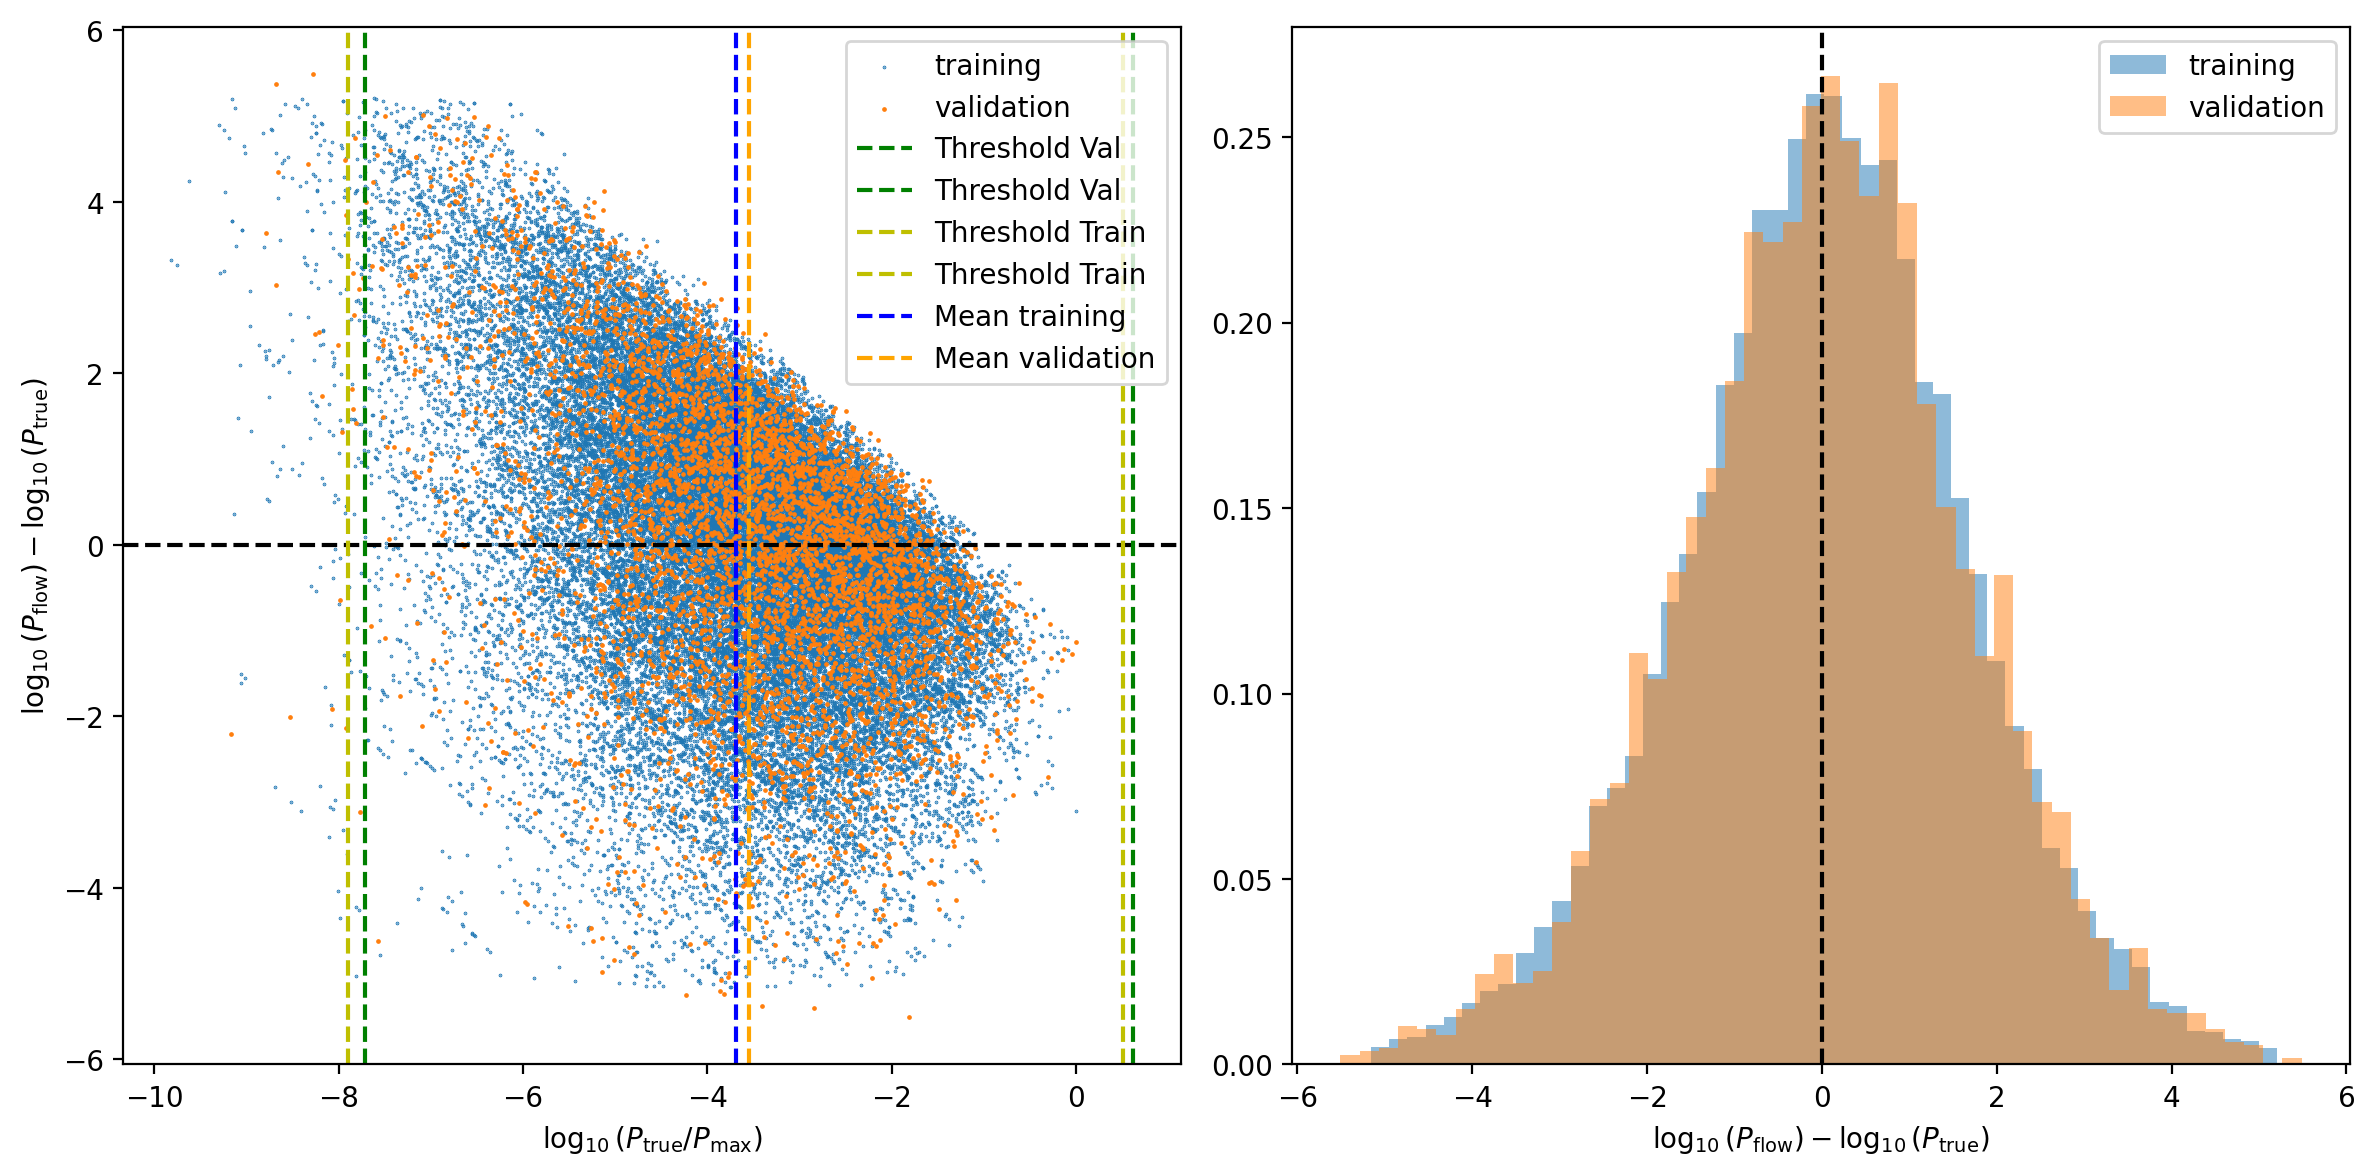

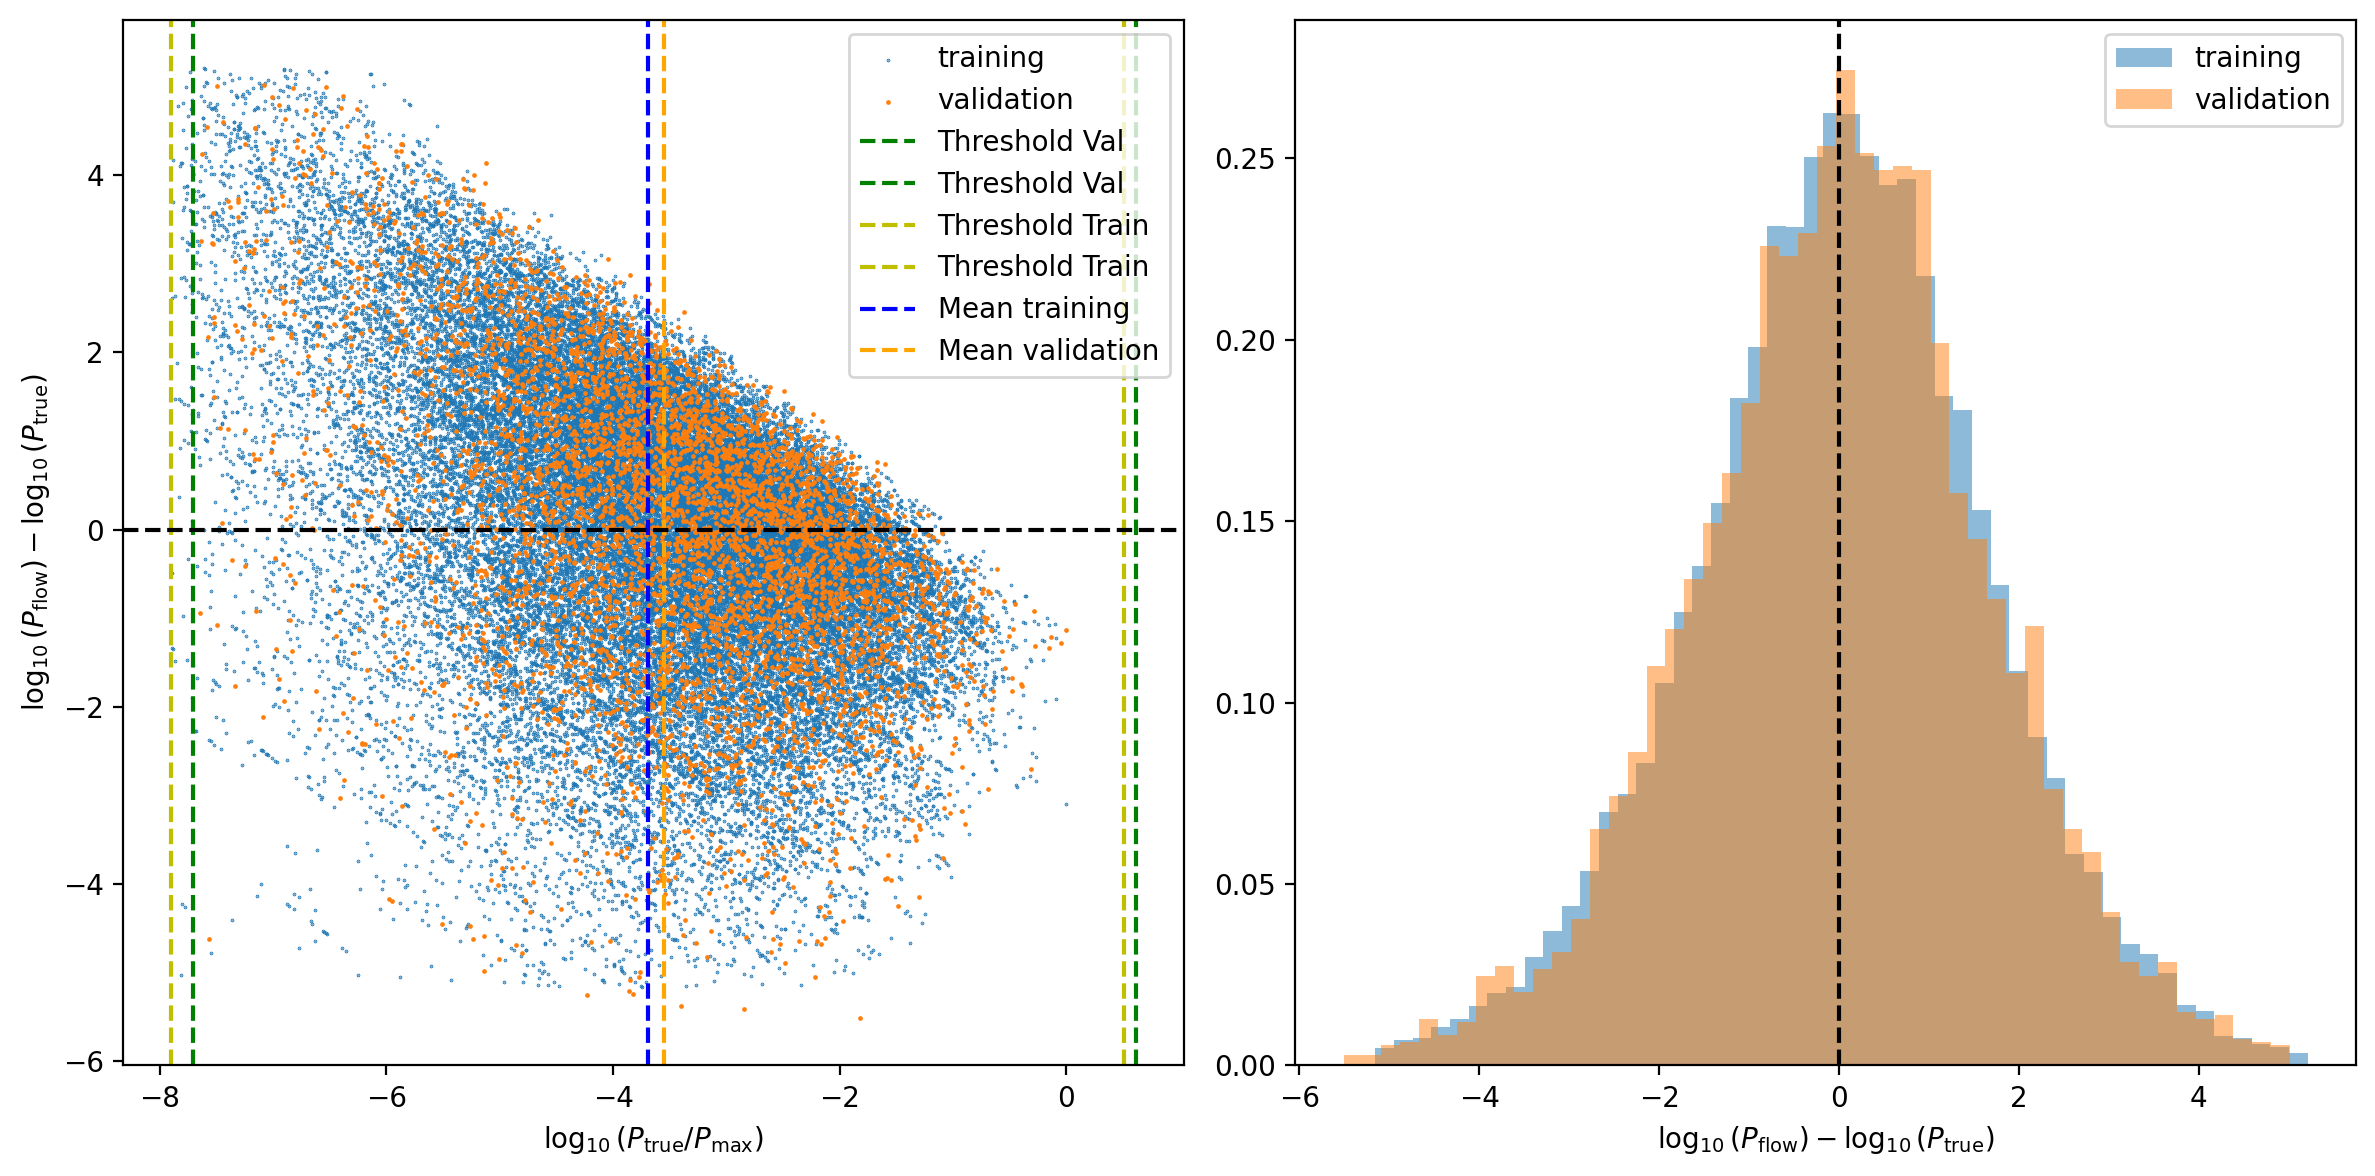

In [19]:
# Now I want to do same thing but studying points far away from the mean of log(Ptrue)/log(Pmax):
# So I want to study:
# training_samples_log10_P - np.amax(training_samples_log10_P)
# validation_samples_log10_P - np.amax(validation_samples_log10_P)
points_train = training_samples_log10_P_del - np.amax(training_samples_log10_P_del)
points_validation = validation_samples_log10_P_del - np.amax(validation_samples_log10_P_del)
mean_training_ratio = np.mean(points_train)
mean_validation_ratio = np.mean(points_validation)
print("Mean training difference from max:", mean_training_ratio)
print("Mean validation difference from max:", mean_validation_ratio)

training_flow_diff_ratio = (points_train) - mean_training_ratio
validation_flow_diff_ratio = (points_validation) - mean_validation_ratio
training_flow_sum_ratio = (points_train) + mean_training_ratio
validation_flow_sum_ratio = (points_validation) + mean_validation_ratio
print("Training flow difference ratio:", training_flow_diff_ratio[:3])
print("Validation flow difference ratio:", validation_flow_diff_ratio[:3])
print("Training flow sum ratio:", training_flow_sum_ratio[:3])
print("Validation flow sum ratio:", validation_flow_sum_ratio[:3])

threshold_training_ratio = 3*np.std(points_train)
threshold_validation_ratio = 3*np.std(points_validation)
print("Threshold training:", threshold_training_ratio)
print("Threshold validation:", threshold_validation_ratio)
cont_train_ratio = 0
cont_val_ratio = 0
validation_samples_log10_P_del_ratio = []
validation_flow_log10_P_del_ratio = []
training_flow_log10_P_del_ratio = []
training_samples_log10_P_del_ratio = []

# I want to see which points are far from the mean and save another array with all points without the removed points:
for i, diff in enumerate(points_train): # points_train = training_samples_log10_P_del - np.amax(training_samples_log10_P_del)
    if np.abs(diff - mean_training_ratio) > threshold_training_ratio: # np.abs(training_x_ratio - mean_training_ratio) <= threshold_training_ratio
        #print(f"Training point {i} is far from the mean: {diff}")
        cont_train_ratio += 1
        # create a new array with the points that are not far from the mean:
    else:
        training_samples_log10_P_del_ratio.append(training_samples_log10_P_del[i])
        training_flow_log10_P_del_ratio.append(training_flow_log10_P_del[i])
        #print(f"Training point {i} is not far from the mean: {diff}")

for i, diff in enumerate(points_validation):
    if np.abs(diff - mean_validation_ratio) > threshold_validation_ratio:
        #print(f"Validation point {i} is far from the mean: {diff}")
        cont_val_ratio += 1
        # create a new array with the points that are not far from the mean:
    else:
        validation_samples_log10_P_del_ratio.append(validation_samples_log10_P_del[i])
        validation_flow_log10_P_del_ratio.append(validation_flow_log10_P_del[i])
        #print(f"Validation point {i} is not far from the mean: {diff}")
        
print(f"Number of training points far from the mean: {cont_train_ratio}")
print(f"Number of validation points far from the mean: {cont_val_ratio}")


# Convert lists to numpy arrays:
training_samples_log10_P_del_ratio = np.array(training_samples_log10_P_del_ratio)
training_flow_log10_P_del_ratio = np.array(training_flow_log10_P_del_ratio)
validation_samples_log10_P_del_ratio = np.array(validation_samples_log10_P_del_ratio)
validation_flow_log10_P_del_ratio = np.array(validation_flow_log10_P_del_ratio)

# do the plot:

# Without the removed points for del:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.scatter(training_samples_log10_P_del - np.amax(training_samples_log10_P_del), training_flow_log10_P_del - training_samples_log10_P_del, s=0.1, label='training')
ax1.scatter(validation_samples_log10_P_del - np.amax(validation_samples_log10_P_del), validation_flow_log10_P_del - validation_samples_log10_P_del, s=0.5, label='validation')
ax1.legend()
ax1.axhline(0, color='k', linestyle='--')
# vertical lines for the thresholds:
ax1.axvline(mean_validation_ratio - threshold_validation_ratio, color='g', linestyle='--', label='Threshold Val')
ax1.axvline(mean_validation_ratio + threshold_validation_ratio, color='g', linestyle='--', label='Threshold Val')
ax1.axvline(mean_training_ratio - threshold_training_ratio, color='y', linestyle='--', label='Threshold Train')
ax1.axvline(mean_training_ratio + threshold_training_ratio, color='y', linestyle='--', label='Threshold Train')
# vertical lines for the mean:
ax1.axvline(mean_training_ratio, color='b', linestyle='--', label='Mean training')
ax1.axvline(mean_validation_ratio, color='orange', linestyle='--', label='Mean validation')
ax1.legend()
ax1.set_xlabel('$\log_{10}(P_{\\rm true}/P_{\\rm max})$')
ax1.set_ylabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')   
ax2.hist(training_flow_log10_P_del - training_samples_log10_P_del, bins=50, density=True, alpha=0.5, label='training')
ax2.hist(validation_flow_log10_P_del - validation_samples_log10_P_del, bins=50, density=True, alpha=0.5, label='validation')
ax2.legend()
ax2.axvline(0, color='k', linestyle='--')
ax2.set_xlabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')  
plt.tight_layout()
plt.show()

# Do the same thing but without the removed points for ratio:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.scatter(training_samples_log10_P_del_ratio - np.amax(training_samples_log10_P_del), 
            training_flow_log10_P_del_ratio - training_samples_log10_P_del_ratio, 
            s=0.1, label='training')
ax1.scatter(validation_samples_log10_P_del_ratio - np.amax(validation_samples_log10_P_del), 
            validation_flow_log10_P_del_ratio - validation_samples_log10_P_del_ratio, 
            s=0.5, label='validation')
ax1.axvline(mean_validation_ratio - threshold_validation_ratio, color='g', linestyle='--', label='Threshold Val')
ax1.axvline(mean_validation_ratio + threshold_validation_ratio, color='g', linestyle='--', label='Threshold Val')
ax1.axvline(mean_training_ratio - threshold_training_ratio, color='y', linestyle='--', label='Threshold Train')
ax1.axvline(mean_training_ratio + threshold_training_ratio, color='y', linestyle='--', label='Threshold Train')
# vertical lines for the mean:
ax1.axvline(mean_training_ratio, color='b', linestyle='--', label='Mean training')
ax1.axvline(mean_validation_ratio, color='orange', linestyle='--', label='Mean validation')
ax1.legend()
ax1.axhline(0, color='k', linestyle='--')
ax1.set_xlabel('$\log_{10}(P_{\\rm true}/P_{\\rm max})$')
ax1.set_ylabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')  
ax2.hist(training_flow_log10_P_del_ratio - training_samples_log10_P_del_ratio, 
         bins=50, density=True, alpha=0.5, label='training')
ax2.hist(validation_flow_log10_P_del_ratio - validation_samples_log10_P_del_ratio, 
         bins=50, density=True, alpha=0.5, label='validation')
ax2.legend()
ax2.axvline(0, color='k', linestyle='--')
ax2.set_xlabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$') 
plt.tight_layout()
plt.show()

In [20]:
training_x_ratio = training_samples_log10_P_del - np.amax(training_samples_log10_P_del)
mean_training_ratio = np.mean(training_x_ratio)

# Mask of valid samples
keep_mask_ratio = np.abs(training_x_ratio - mean_training_ratio) <= threshold_training_ratio

# Convert to list of indices for flow.evidence()
training_filtered_indices_lcdm_ratio = np.where(keep_mask_ratio)[0].tolist()

# Compute evidence
ev_lcdm_ratio, eer_lcdm_ratio = average_flow_lcdm.evidence(indexes=training_filtered_indices_lcdm_ratio, 
                                                           weighted=True)
print(f'LCDM (filtered by Ptrue/Pmax): log(Z) = {ev_lcdm_ratio} ± {eer_lcdm_ratio}')


LCDM (filtered by Ptrue/Pmax): log(Z) = -16213.74077882339 ± 2.686665273511799


evidences: [-16213.882949864306, -16213.869620685613, -16213.863186516597, -16213.796385090956, -16213.828340146842] ... [-16213.742243196953, -16213.742613902336, -16213.742639854785, -16213.742638536407, -16213.742686916923]
Minimum error at index 1, sigma = 0.1393939393939394, log(Z) = -16213.869620685613, error = 2.5937486923467263


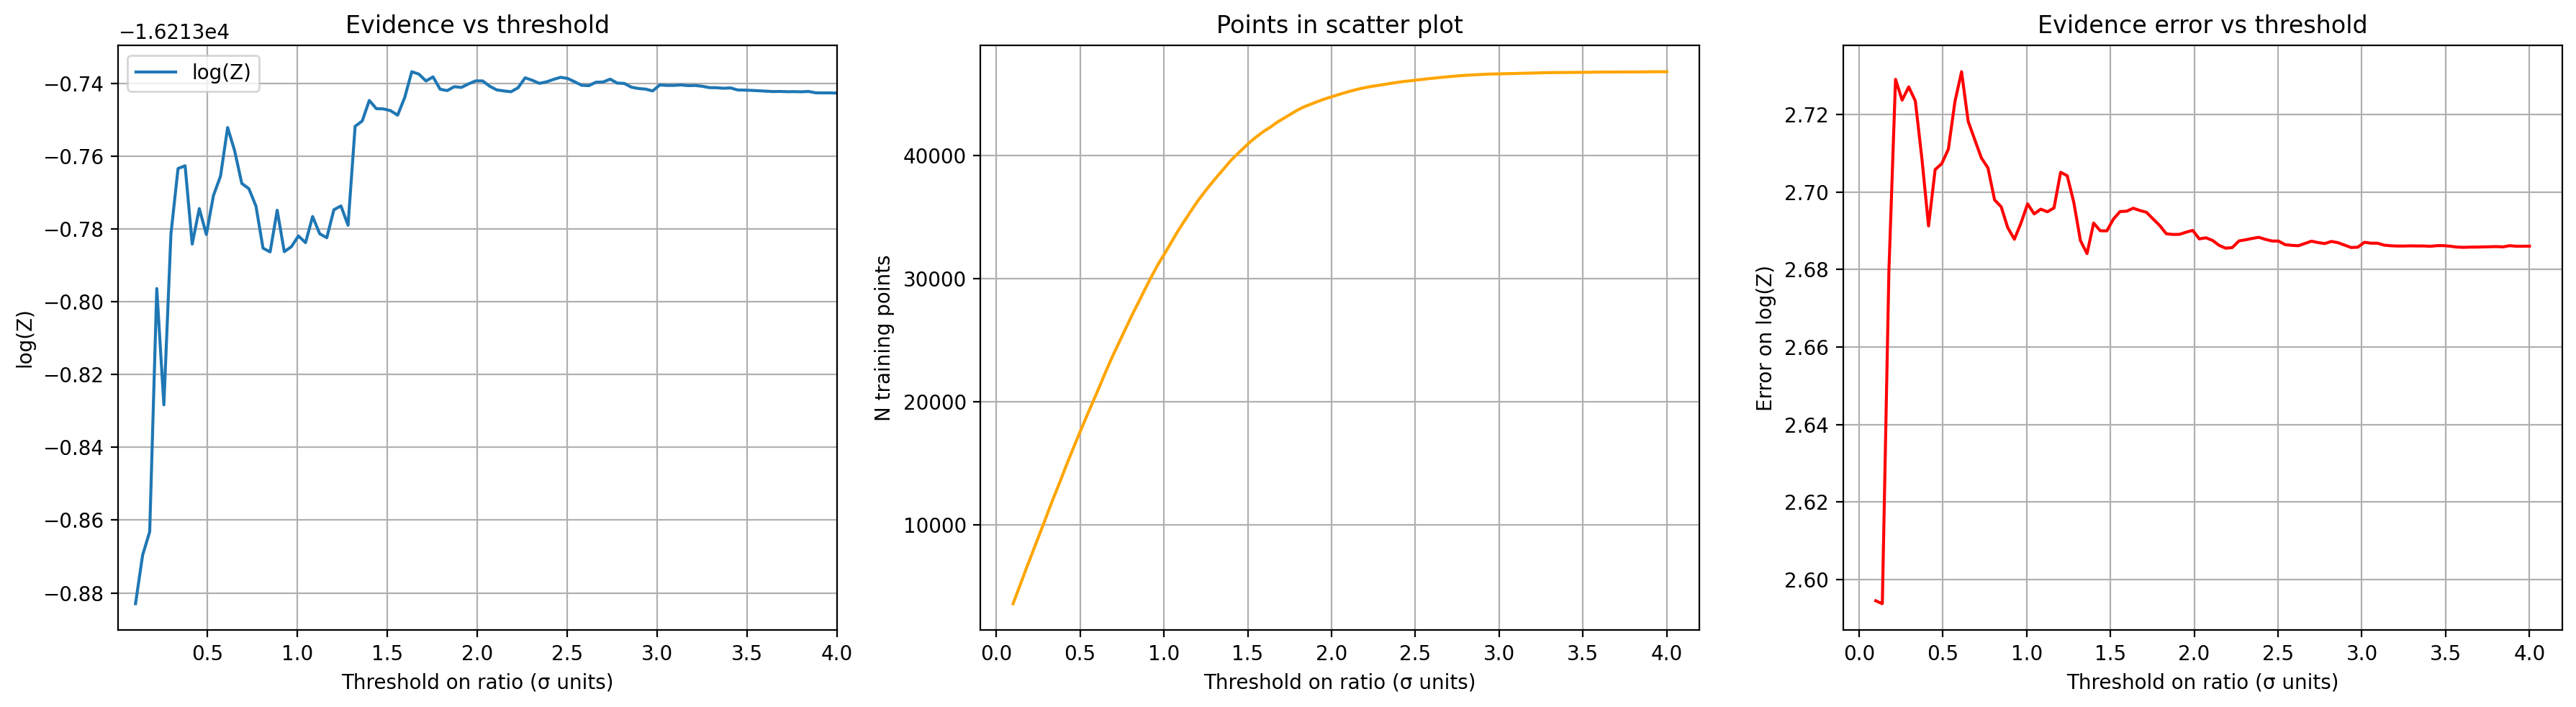

In [27]:

# --- Step 0: prepare values ---
logPtrue = training_samples_log10_P_del

# Probability ratio filter (variable)
logPtrue_ratio = logPtrue - np.amax(logPtrue)
mean_ratio = np.mean(logPtrue_ratio)
std_ratio = np.std(logPtrue_ratio)

# Grid of thresholds
sigmas = np.linspace(0.1, 4.0, 100)
evidences = []
errors = []
n_points = []

for s in sigmas:
    threshold_ratio = s * std_ratio
    mask_ratio = np.abs(logPtrue_ratio - mean_ratio) <= threshold_ratio
    indices = np.where(mask_ratio)[0].tolist()

    if len(indices) > 0:
        ev, err = average_flow_lcdm.evidence(indexes=indices, weighted=True)
    else:
        ev, err = np.nan, np.nan

    evidences.append(ev)
    errors.append(err)
    n_points.append(len(indices))
print(f"evidences: {evidences[:5]} ... {evidences[-5:]}")

#find minimum of error
min_error_index = np.argmin(errors)
print(f"Minimum error at index {min_error_index}, sigma = {sigmas[min_error_index]}, log(Z) = {evidences[min_error_index]}, error = {errors[min_error_index]}")

# --- Plotting ---
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Evidence
axs[0].plot(sigmas, evidences, label='log(Z)')
#axs[0].fill_between(sigmas,
                   # np.array(evidences) - np.array(errors),
                    #np.array(evidences) + np.array(errors),
                    #alpha=0.3, label='±1σ')
axs[0].set_xlabel('Threshold on ratio (σ units)')
axs[0].set_ylabel('log(Z)')
axs[0].set_title('Evidence vs threshold')
#set limit on x-axis
axs[0].set_xlim(0.001, 4)
axs[0].legend()
axs[0].grid(True)

# Plot 2: Number of retained points
axs[1].plot(sigmas, n_points, color='orange')
axs[1].set_xlabel('Threshold on ratio (σ units)')
axs[1].set_ylabel('N training points')
axs[1].set_title('Points in scatter plot')
axs[1].grid(True)

# Plot 3: Error on evidence
axs[2].plot(sigmas, errors, color='red')
axs[2].set_xlabel('Threshold on ratio (σ units)')
axs[2].set_ylabel('Error on log(Z)')
axs[2].set_title('Evidence error vs threshold')
axs[0].set_xlim(0.001, 4)
axs[2].grid(True)

plt.tight_layout()
plt.show()


evidences: [-16215.636, -16215.6, -16215.602, -16215.545, -16215.555] ... [-16215.553, -16215.553, -16215.553, -16215.553, -16215.553]
Minimum error at index 2, sigma = 0.17878787878787877, log(Z) = -16215.6015625, error = 3.8566620349884033


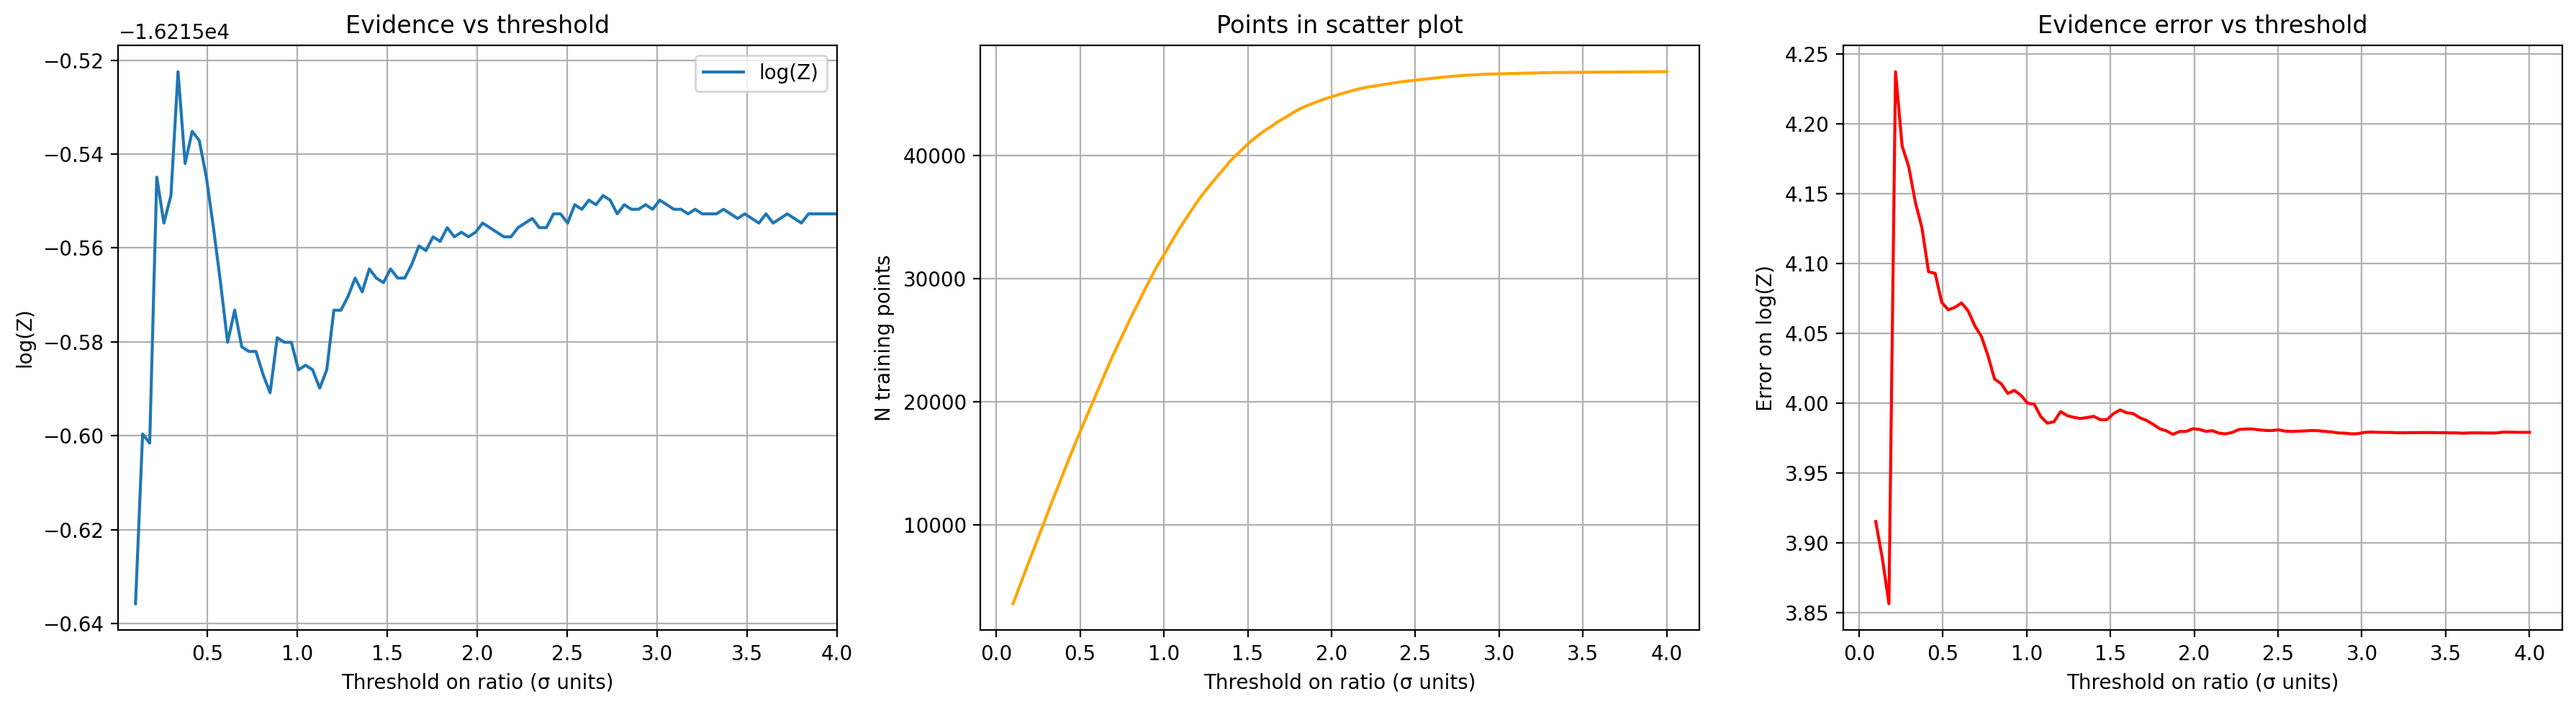

In [28]:
# Do the same but with weighted=False

# --- Step 0: prepare values ---
logPtrue = training_samples_log10_P_del

# Probability ratio filter (variable)
logPtrue_ratio = logPtrue - np.amax(logPtrue)
mean_ratio = np.mean(logPtrue_ratio)
std_ratio = np.std(logPtrue_ratio)

# Grid of thresholds
sigmas = np.linspace(0.1, 4.0, 100)
evidences = []
errors = []
n_points = []

for s in sigmas:
    threshold_ratio = s * std_ratio
    mask_ratio = np.abs(logPtrue_ratio - mean_ratio) <= threshold_ratio
    indices = np.where(mask_ratio)[0].tolist()

    if len(indices) > 0:
        ev, err = average_flow_lcdm.evidence(indexes=indices, weighted=False)
    else:
        ev, err = np.nan, np.nan

    evidences.append(ev)
    errors.append(err)
    n_points.append(len(indices))
print(f"evidences: {evidences[:5]} ... {evidences[-5:]}")

#find minimum of error
min_error_index = np.argmin(errors)
print(f"Minimum error at index {min_error_index}, sigma = {sigmas[min_error_index]}, log(Z) = {evidences[min_error_index]}, error = {errors[min_error_index]}")

# --- Plotting ---
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Evidence
axs[0].plot(sigmas, evidences, label='log(Z)')
#axs[0].fill_between(sigmas,
                   # np.array(evidences) - np.array(errors),
                    #np.array(evidences) + np.array(errors),
                    #alpha=0.3, label='±1σ')
axs[0].set_xlabel('Threshold on ratio (σ units)')
axs[0].set_ylabel('log(Z)')
axs[0].set_title('Evidence vs threshold')
#set limit on x-axis
axs[0].set_xlim(0.001, 4)
axs[0].legend()
axs[0].grid(True)

# Plot 2: Number of retained points
axs[1].plot(sigmas, n_points, color='orange')
axs[1].set_xlabel('Threshold on ratio (σ units)')
axs[1].set_ylabel('N training points')
axs[1].set_title('Points in scatter plot')
axs[1].grid(True)

# Plot 3: Error on evidence
axs[2].plot(sigmas, errors, color='red')
axs[2].set_xlabel('Threshold on ratio (σ units)')
axs[2].set_ylabel('Error on log(Z)')
axs[2].set_title('Evidence error vs threshold')
axs[0].set_xlim(0.001, 4)
axs[2].grid(True)

plt.tight_layout()
plt.show()


## ALTRA PROVA: TOLGO SOLO A SINISTRA DELLA LINEA VERTICALE

Number of training points far from the mean: 3047
Number of validation points far from the mean: 287


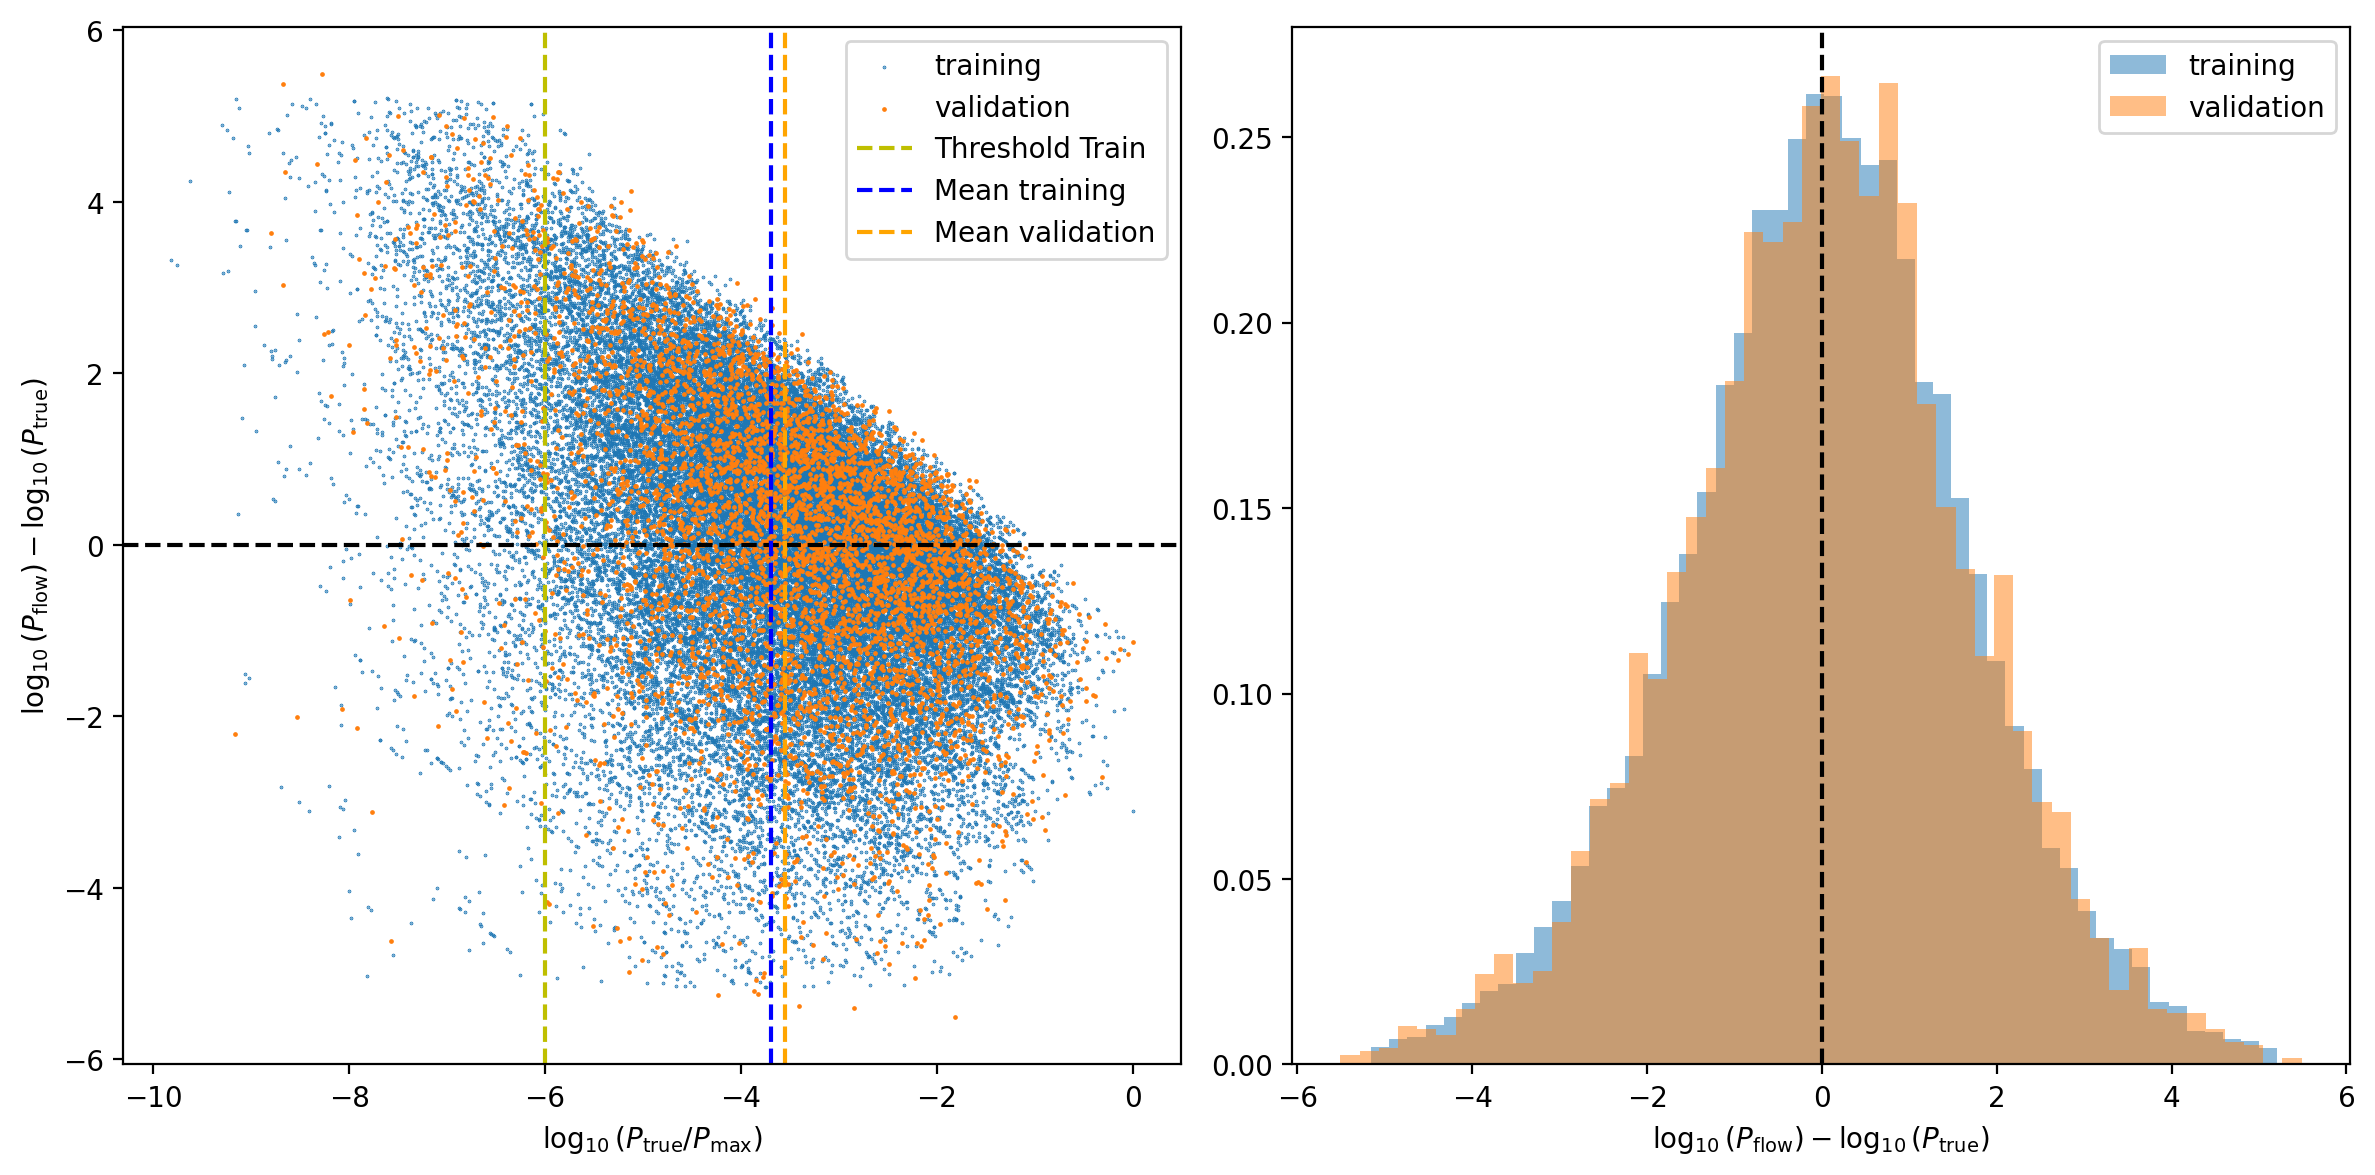

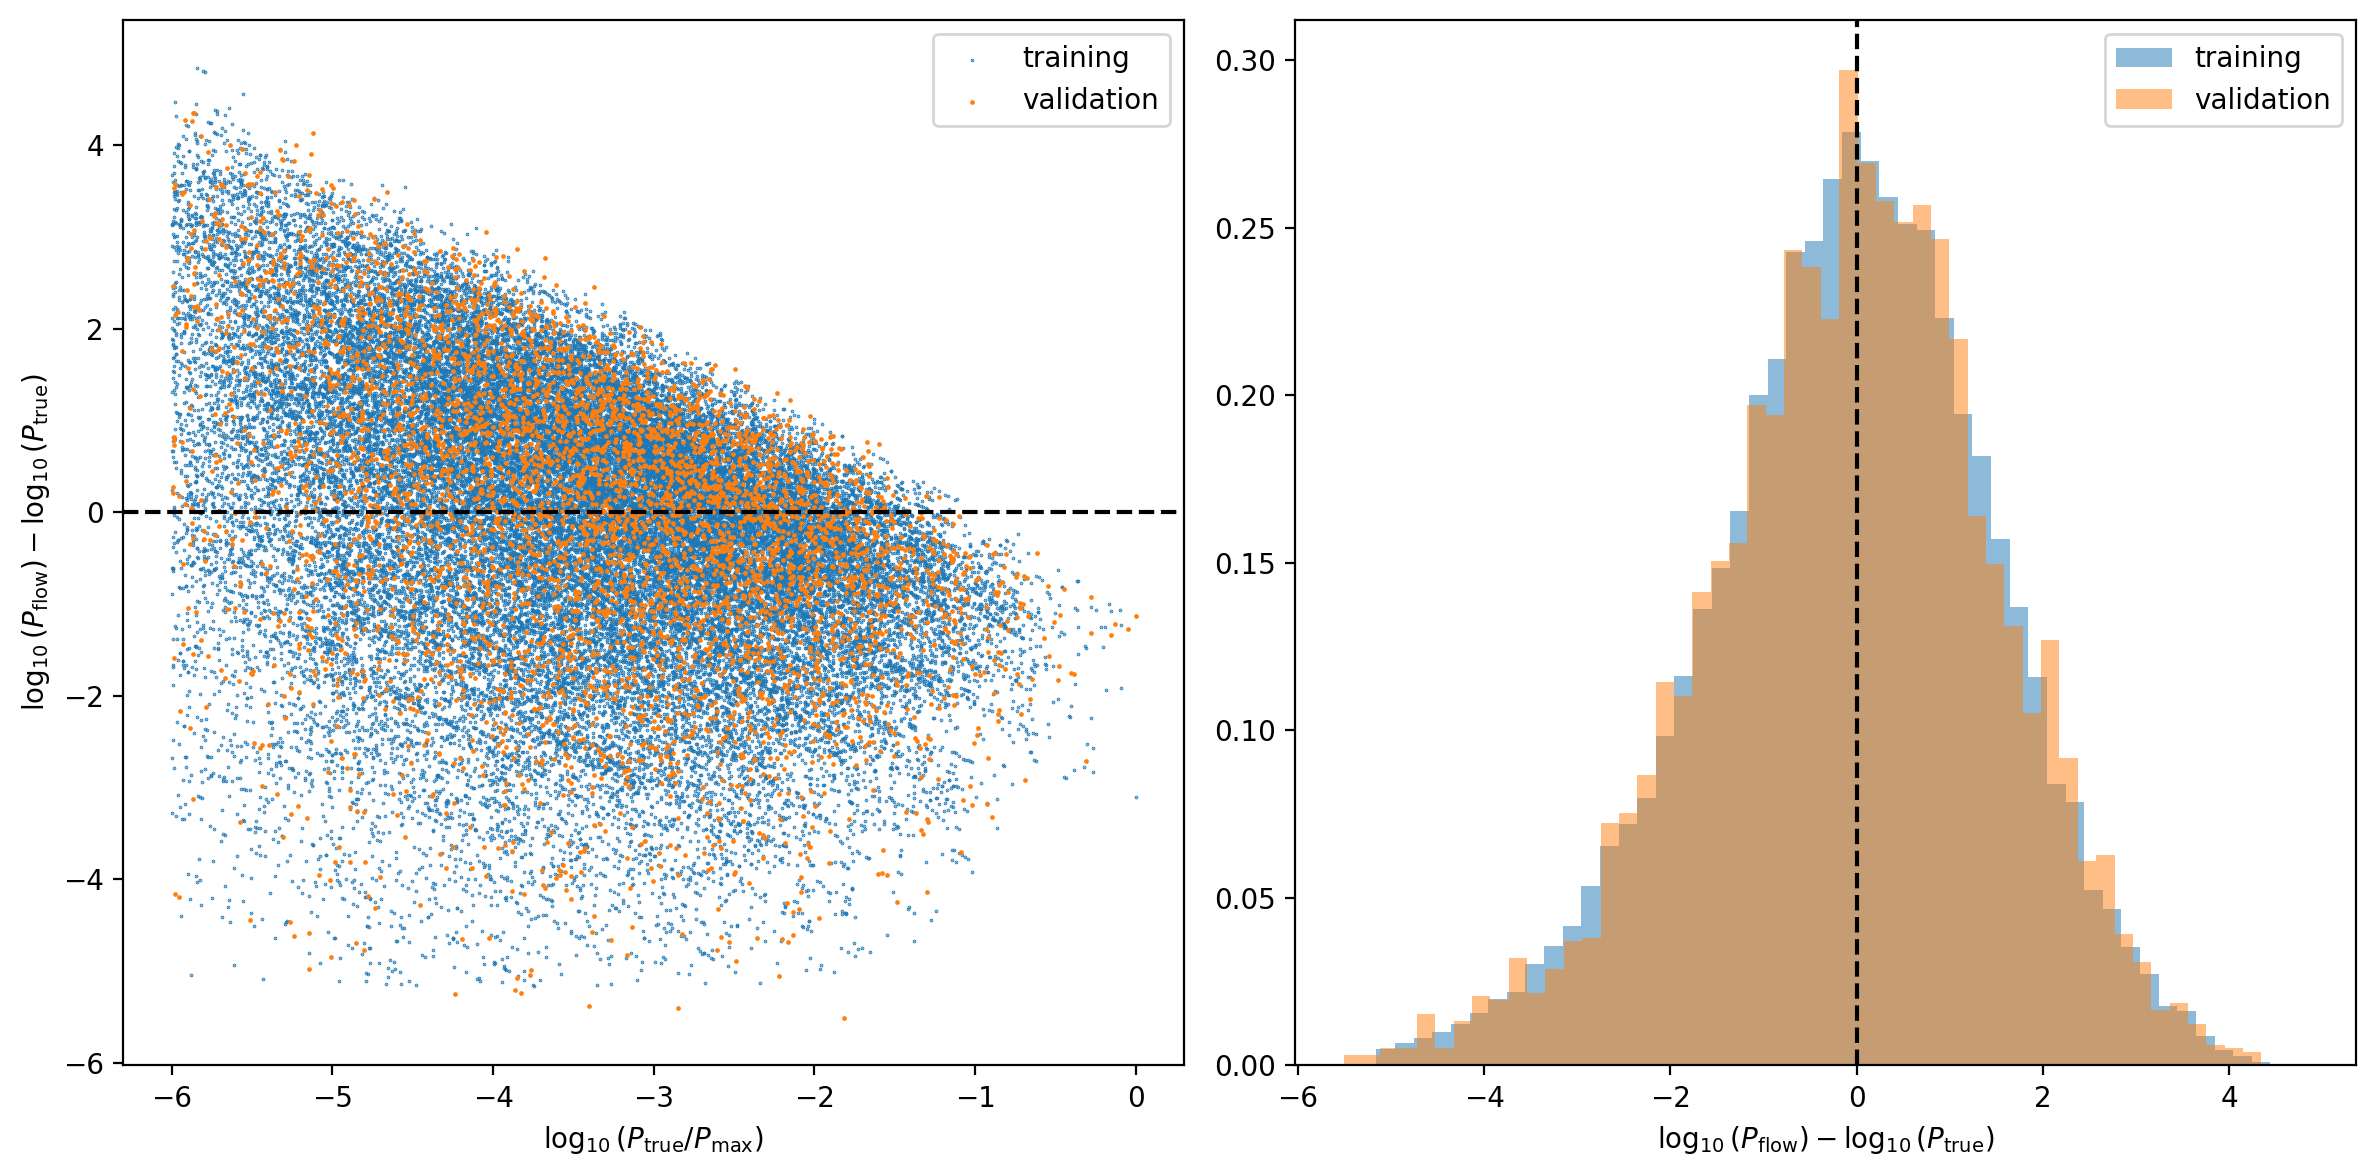

In [23]:
#########################################################################################

x_cut = -6  # <-- your new vertical threshold

cont_train_ratio = 0
cont_val_ratio = 0
training_samples_log10_P_del_ratio = []
training_flow_log10_P_del_ratio = []
validation_samples_log10_P_del_ratio = []
validation_flow_log10_P_del_ratio = []

for i in range(len(points_train)):
    if points_train[i] > x_cut:
        training_samples_log10_P_del_ratio.append(training_samples_log10_P_del[i])
        training_flow_log10_P_del_ratio.append(training_flow_log10_P_del[i])
    else:
        cont_train_ratio += 1

for i in range(len(points_validation)):
    if points_validation[i] > x_cut:
        validation_samples_log10_P_del_ratio.append(validation_samples_log10_P_del[i])
        validation_flow_log10_P_del_ratio.append(validation_flow_log10_P_del[i])
    else:
        cont_val_ratio += 1


#########################################################################################

        
print(f"Number of training points far from the mean: {cont_train_ratio}")
print(f"Number of validation points far from the mean: {cont_val_ratio}")


# Convert lists to numpy arrays:
training_samples_log10_P_del_ratio = np.array(training_samples_log10_P_del_ratio)
training_flow_log10_P_del_ratio = np.array(training_flow_log10_P_del_ratio)
validation_samples_log10_P_del_ratio = np.array(validation_samples_log10_P_del_ratio)
validation_flow_log10_P_del_ratio = np.array(validation_flow_log10_P_del_ratio)

# do the plot:

# Without the removed points for del:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.scatter(training_samples_log10_P_del - np.amax(training_samples_log10_P_del), training_flow_log10_P_del - training_samples_log10_P_del, s=0.1, label='training')
ax1.scatter(validation_samples_log10_P_del - np.amax(validation_samples_log10_P_del), validation_flow_log10_P_del - validation_samples_log10_P_del, s=0.5, label='validation')
ax1.legend()
ax1.axhline(0, color='k', linestyle='--')
# vertical lines for the thresholds:
#ax1.axvline(mean_validation_ratio - threshold_validation_ratio, color='g', linestyle='--', label='Threshold Val')
#ax1.axvline(mean_validation_ratio + threshold_validation_ratio, color='g', linestyle='--', label='Threshold Val')
#ax1.axvline(mean_training_ratio - threshold_training_ratio, color='y', linestyle='--', label='Threshold Train')
#ax1.axvline(mean_training_ratio + threshold_training_ratio, color='y', linestyle='--', label='Threshold Train')
ax1.axvline(x_cut, color='y', linestyle='--', label='Threshold Train')
# vertical lines for the mean:
ax1.axvline(mean_training_ratio, color='b', linestyle='--', label='Mean training')
ax1.axvline(mean_validation_ratio, color='orange', linestyle='--', label='Mean validation')
ax1.legend()
ax1.set_xlabel('$\log_{10}(P_{\\rm true}/P_{\\rm max})$')
ax1.set_ylabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')   
ax2.hist(training_flow_log10_P_del - training_samples_log10_P_del, bins=50, density=True, alpha=0.5, label='training')
ax2.hist(validation_flow_log10_P_del - validation_samples_log10_P_del, bins=50, density=True, alpha=0.5, label='validation')
ax2.legend()
ax2.axvline(0, color='k', linestyle='--')
ax2.set_xlabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')  
plt.tight_layout()
plt.show()

# Do the same thing but without the removed points for ratio:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.scatter(training_samples_log10_P_del_ratio - np.amax(training_samples_log10_P_del), 
            training_flow_log10_P_del_ratio - training_samples_log10_P_del_ratio, 
            s=0.1, label='training')
ax1.scatter(validation_samples_log10_P_del_ratio - np.amax(validation_samples_log10_P_del), 
            validation_flow_log10_P_del_ratio - validation_samples_log10_P_del_ratio, 
            s=0.5, label='validation')
#ax1.axvline(mean_validation_ratio - threshold_validation_ratio, color='g', linestyle='--', label='Threshold Val')
#ax1.axvline(mean_validation_ratio + threshold_validation_ratio, color='g', linestyle='--', label='Threshold Val')
#ax1.axvline(mean_training_ratio - threshold_training_ratio, color='y', linestyle='--', label='Threshold Train')
#ax1.axvline(mean_training_ratio + threshold_training_ratio, color='y', linestyle='--', label='Threshold Train')
# vertical lines for the mean:
#ax1.axvline(mean_training_ratio, color='b', linestyle='--', label='Mean training')
#ax1.axvline(mean_validation_ratio, color='orange', linestyle='--', label='Mean validation')
ax1.legend()
ax1.axhline(0, color='k', linestyle='--')
ax1.set_xlabel('$\log_{10}(P_{\\rm true}/P_{\\rm max})$')
ax1.set_ylabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')  
ax2.hist(training_flow_log10_P_del_ratio - training_samples_log10_P_del_ratio, 
         bins=50, density=True, alpha=0.5, label='training')
ax2.hist(validation_flow_log10_P_del_ratio - validation_samples_log10_P_del_ratio, 
         bins=50, density=True, alpha=0.5, label='validation')
ax2.legend()
ax2.axvline(0, color='k', linestyle='--')
ax2.set_xlabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$') 
plt.tight_layout()
plt.show()

In [29]:

# Compute the evidence:
training_x_ratio = training_samples_log10_P_del - np.amax(training_samples_log10_P_del)
mean_training_ratio = np.mean(training_x_ratio)

# Mask of valid samples
keep_mask_ratio = training_x_ratio > x_cut

# Convert to list of indices for flow.evidence()
training_filtered_indices_lcdm_ratio = np.where(keep_mask_ratio)[0].tolist()

# Compute evidence
ev_lcdm_ratio, eer_lcdm_ratio = average_flow_lcdm.evidence(indexes=training_filtered_indices_lcdm_ratio, 
                                                           weighted=True)
print(f'LCDM (filtered by Ptrue/Pmax): log(Z) = {ev_lcdm_ratio} ± {eer_lcdm_ratio}')


LCDM (filtered by Ptrue/Pmax): log(Z) = -16215.024009953351 ± 1.751349557469562


evidences: [-16213.74259358123, -16213.74259358123, -16213.74259358123, -16213.74259358123, -16213.74259358123] ... [-16214.16856432447, -16213.8315934857, -16214.488442336084, -16214.737445382512, -16215.024009953351]
Minimum error at index 99, x_cut = -0.4, log(Z) = -16215.024009953351, error = 1.751349557469562
Maximum error at index 94, x_cut = -0.9858585858585869, log(Z) = -16214.093561441941, error = 2.8446381531519123


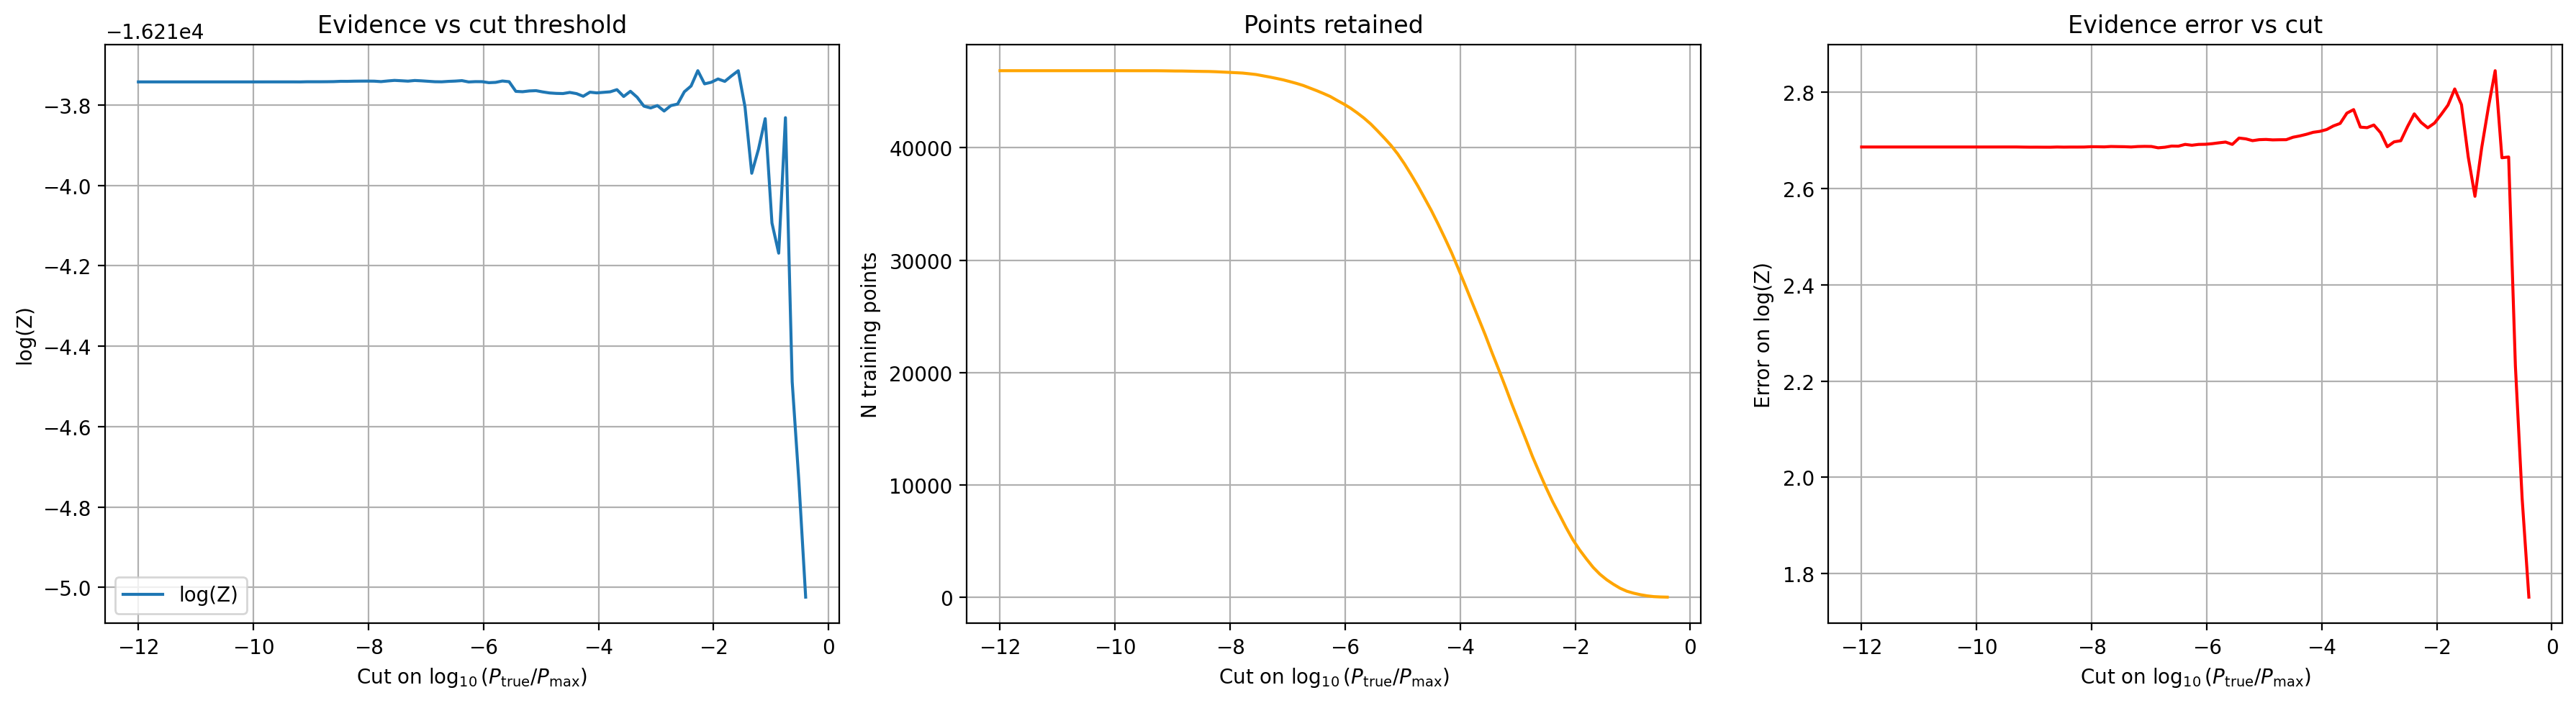

In [30]:

# --- Step 0: prepare values ---
logPtrue = training_samples_log10_P_del

# Probability ratio from maximum
logPtrue_ratio = logPtrue - np.amax(logPtrue)

# Grid of fixed cuts (e.g., from left to right)
x_cuts = np.linspace(-12, -0.4, 100)
evidences = []
errors = []
n_points = []

for x_cut in x_cuts:
    # Keep only points to the right of the cut (greater than threshold)
    mask = logPtrue_ratio > x_cut
    indices = np.where(mask)[0].tolist()

    if len(indices) > 0:
        ev, err = average_flow_lcdm.evidence(indexes=indices, weighted=True)
    else:
        ev, err = np.nan, np.nan

    evidences.append(ev)
    errors.append(err)
    n_points.append(len(indices))

print(f"evidences: {evidences[:5]} ... {evidences[-5:]}")

# Find minimum error index
min_error_index = np.nanargmin(errors)
print(f"Minimum error at index {min_error_index}, x_cut = {x_cuts[min_error_index]}, log(Z) = {evidences[min_error_index]}, error = {errors[min_error_index]}")
# Find maximum error index
max_error_index = np.nanargmax(errors)
print(f"Maximum error at index {max_error_index}, x_cut = {x_cuts[max_error_index]}, log(Z) = {evidences[max_error_index]}, error = {errors[max_error_index]}")

# --- Plotting ---
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Evidence
axs[0].plot(x_cuts, evidences, label='log(Z)')
axs[0].set_xlabel('Cut on $\log_{10}(P_{\\rm true}/P_{\\rm max})$')
axs[0].set_ylabel('log(Z)')
axs[0].set_title('Evidence vs cut threshold')
axs[0].legend()
axs[0].grid(True)

# Plot 2: Number of retained points
axs[1].plot(x_cuts, n_points, color='orange')
axs[1].set_xlabel('Cut on $\log_{10}(P_{\\rm true}/P_{\\rm max})$')
axs[1].set_ylabel('N training points')
axs[1].set_title('Points retained')
axs[1].grid(True)

# Plot 3: Error on evidence
axs[2].plot(x_cuts, errors, color='red')
axs[2].set_xlabel('Cut on $\log_{10}(P_{\\rm true}/P_{\\rm max})$')
axs[2].set_ylabel('Error on log(Z)')
axs[2].set_title('Evidence error vs cut')
axs[2].grid(True)

plt.tight_layout()
plt.show()


evidences: [-16215.552, -16215.552, -16215.552, -16215.552, -16215.552] ... [-16215.365, -16215.045, -16215.267, -16214.955, -16215.114]
Minimum error at index 99, x_cut = -0.4, log(Z) = -16215.1142578125, error = 3.2646398544311523
Maximum error at index 93, x_cut = -1.1030303030303035, log(Z) = -16215.5146484375, error = 4.049830913543701


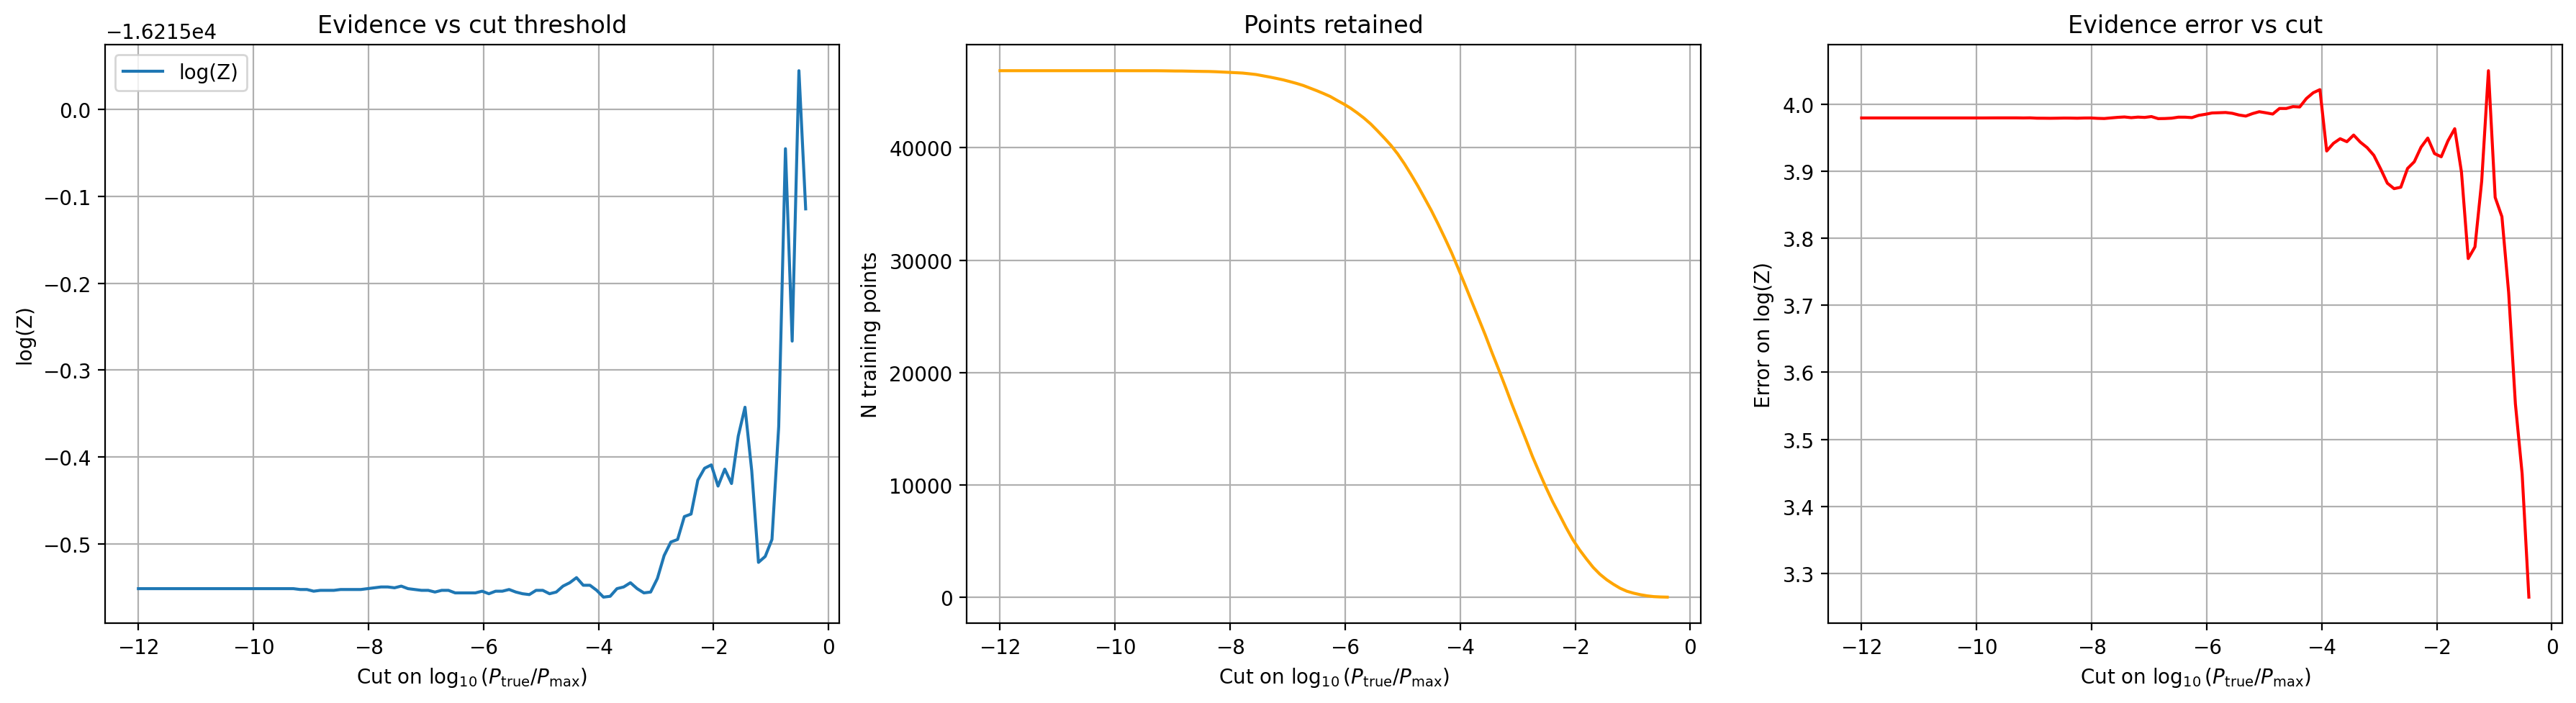

In [ ]:
# Do the same but with weighted=False

# --- Step 0: prepare values ---
logPtrue = training_samples_log10_P_del

# Probability ratio from maximum
logPtrue_ratio = logPtrue - np.amax(logPtrue)

# Grid of fixed cuts (e.g., from left to right)
x_cuts = np.linspace(-12, -0.4, 100)
evidences = []
errors = []
n_points = []

for x_cut in x_cuts:
    # Keep only points to the right of the cut (greater than threshold)
    mask = logPtrue_ratio > x_cut
    indices = np.where(mask)[0].tolist()

    if len(indices) > 0:
        ev, err = average_flow_lcdm.evidence(indexes=indices, weighted=False)
    else:
        ev, err = np.nan, np.nan

    evidences.append(ev)
    errors.append(err)
    n_points.append(len(indices))

print(f"evidences: {evidences[:5]} ... {evidences[-5:]}")

# Find minimum error index
min_error_index = np.nanargmin(errors)
print(f"Minimum error at index {min_error_index}, x_cut = {x_cuts[min_error_index]}, log(Z) = {evidences[min_error_index]}, error = {errors[min_error_index]}")
# Find maximum error index
max_error_index = np.nanargmax(errors)
print(f"Maximum error at index {max_error_index}, x_cut = {x_cuts[max_error_index]}, log(Z) = {evidences[max_error_index]}, error = {errors[max_error_index]}")

# --- Plotting ---
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Evidence
axs[0].plot(x_cuts, evidences, label='log(Z)')
axs[0].set_xlabel('Cut on $\log_{10}(P_{\\rm true}/P_{\\rm max})$')
axs[0].set_ylabel('log(Z)')
axs[0].set_title('Evidence vs cut threshold')
axs[0].legend()
axs[0].grid(True)

# Plot 2: Number of retained points
axs[1].plot(x_cuts, n_points, color='orange')
axs[1].set_xlabel('Cut on $\log_{10}(P_{\\rm true}/P_{\\rm max})$')
axs[1].set_ylabel('N training points')
axs[1].set_title('Points retained')
axs[1].grid(True)

# Plot 3: Error on evidence
axs[2].plot(x_cuts, errors, color='red')
axs[2].set_xlabel('Cut on $\log_{10}(P_{\\rm true}/P_{\\rm max})$')
axs[2].set_ylabel('Error on log(Z)')
axs[2].set_title('Evidence error vs cut')
axs[2].grid(True)

plt.tight_layout()
plt.show()
